In [30]:
from __future__ import division, print_function
import bilby
from gwpy.timeseries import TimeSeries
import math
from bilby.gw.conversion import component_masses_to_chirp_mass, component_masses_to_symmetric_mass_ratio, luminosity_distance_to_redshift, chirp_mass_and_mass_ratio_to_component_masses
from bilby.core import utils
import numpy as np
from gwosc import datasets
from astropy import constants as const
import sys
import argparse
import configparser
import os
import errno
import json
import datetime
import scipy.signal.windows as windows
import matplotlib.pyplot as plt
from bilby.core.utils import infft

plt.style.use('~/research/my_plot_style.style')

"""get current time"""
start = datetime.datetime.now()

"""constants"""
Mo = const.M_sun.value #solar mass [kg]
G = const.G.value #Newton constant [m^3 kg^-1 s^2]
c = const.c.value #light speed [m s^-1]
pc = const.pc.value #1pc [m]

"""get ringdown waveform from config file"""
def get_ringdown_waveform_from_config(config_file_path, method='Mirror', domain='f', get_each_overtone=False):

    config_path = config_file_path
    config_ini = configparser.ConfigParser()
    config_ini.read(config_path)

    config_setting = config_ini['setting']
    config_injection = config_ini['injection_parameters']
    config_wf_args = config_ini['waveform_arguments']
    config_others = config_ini['other_parameters']

    """set the event to be analyzed"""
    event_name = config_setting['event_name']
    outdir_path = config_setting['outdir_path']
    outdir = outdir_path + 'outdir_' + event_name
    label = event_name
    logger = bilby.core.utils.logger
    bilby.core.utils.setup_logger(outdir=outdir, label=label)

    """output to .log file"""
    comment = config_setting['comment']
    bilby.core.utils.logger.info(comment.replace('_', ' '))
    bilby.core.utils.logger.info('event_name : '+event_name)

    one_mode=False
    mode_number = config_setting['mode_number']
    if mode_number=='one_mode':
        one_mode=True
    bilby.core.utils.logger.info('mode_number : '+mode_number)

    """parameterization"""
    parameterization = config_setting['parameterization']
    bilby.core.utils.logger.info('parameterization : '+parameterization)

    """mode number"""
    one_mode=False
    mode_number = config_setting['mode_number']
    if mode_number=='one_mode':
        one_mode=True
    bilby.core.utils.logger.info('one_mode : '+str(one_mode))

    analysis_one_mode = False
    analysis_mode_number = config_setting['analysis_mode_number']
    if analysis_mode_number=='analysis_one_mode':
        analysis_one_mode = True
    bilby.core.utils.logger.info('analysis_one_mode : '+str(analysis_one_mode))

    """output waveform args"""
    for key in config_wf_args.keys():
        bilby.core.utils.logger.info('{0} : {1}'.format(key, config_wf_args[key]))
    
    """window duration for signal roll on"""
    signal_roll_on_duration = 0.001  #default:0.001s
    if 'signal_roll_on_duration' in config_setting.keys():
        signal_roll_on_duration = float(config_setting['signal_roll_on_duration'])
    bilby.core.utils.logger.info('signal_roll_on_duration : {}'.format(signal_roll_on_duration))

    """waveform"""
    def toy_model_of_two_QNMs_window(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
    
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        tidx = time >= geocent_time

        waveform1[tidx] = A / delta_w * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = -A / delta_w * (1 + delta_w * alpha) * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index

        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        total_waveform[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window

        return {"plus": plus, "cross": cross}

    def toy_model_of_two_QNMs_Heaviside(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        tidx = time >= geocent_time

        waveform1[tidx] = A / delta_w * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = -A / delta_w * (1 + delta_w * alpha) * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window

        return {"plus": plus, "cross": cross}

    def toy_model_of_two_QNMs_Mirror(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17 / np.sqrt(2)

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        waveform1 = A / delta_w * np.exp(1j * (2*np.pi*f1 * (time - geocent_time)) + 1j * phi1) * np.exp(- np.abs(time - geocent_time) / tau1)
        waveform2 = -A / delta_w * (1 + delta_w * alpha) * np.exp(1j * (2*np.pi*f2 * (time - geocent_time)) + 1j * phi2) * np.exp(- np.abs(time - geocent_time) / tau2)

        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window

        return {"plus": plus, "cross": cross}

    # def get_each_overtone(time, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time):
    #     """
    #     Returns
    #     -------
    #     dict:
    #         A dictionary containing "waveform1", "waveform2", and "plus" entries.
    #     """
    #     waveform1 = np.zeros(len(time), dtype=complex)
    #     waveform2 = np.zeros(len(time), dtype=complex)

    #     A = A * 1e-20
    #     w1 = (2*np.pi*f1 + 1j / tau1)
    #     w2 = (2*np.pi*f2 + 1j / tau2)
    #     delta_w = w2 - w1

    #     tidx = time >= geocent_time

    #     waveform1[tidx] = A / delta_w * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
    #     waveform2[tidx] = -A * (1 + delta_w * alpha) / delta_w * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

    #     if one_mode:
    #         waveform2 = np.zeros(len(time), dtype=complex)

    #     plus = (waveform1 + waveform2).real
    #     return {"waveform1": waveform1, "waveform2": waveform2, "plus": plus}
    
    def damped_sinusoid(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A1 = A1 * 1e-19
        A2 = A2 * 1e-19
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)

        tidx = time >= geocent_time

        waveform1[tidx] = A1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = A2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        total_waveform = waveform1 + waveform2

        # signal_roll_on_duration=0
        # """roll on windowing"""
        # dt = time[1] - time[0]
        # roll_on_samples = int(signal_roll_on_duration / dt)
        # start_index = np.where(tidx)[0][0]
        # taper_end_index = min(start_index + roll_on_samples, len(time))
        # taper_len = taper_end_index - start_index
        # hann_taper = windows.hann(2 * taper_len)[:taper_len]
        # total_waveform[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window

        return {"plus": plus, "cross": cross}

    def damped_sinusoid_window(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time, signal_roll_on_duration=signal_roll_on_duration):
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A1 = A1 * 1e-19
        A2 = A2 * 1e-19
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)

        tidx = time >= geocent_time

        waveform1[tidx] = A1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = A2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        total_waveform = waveform1 + waveform2

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index
        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        total_waveform[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window

        return {"plus": plus, "cross": cross}
    
    def damped_sinusoid_fdomain_Heaviside(frequency, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        A1 = A1 * 1e-19
        A2 = A2 * 1e-19

        d_positive_1 = (-1j / tau1) + (2 * (frequency + f1) * np.pi)
        d_negative_1 = (-1j / tau1) + (2 * (frequency - f1) * np.pi)
    
        d_positive_2 = (-1j / tau2) + (2 * (frequency + f2) * np.pi)
        d_negative_2 = (-1j / tau2) + (2 * (frequency - f2) * np.pi)
        
        plus = A1 * ((-1/tau1 - 1j*2*np.pi*frequency) * np.cos(phi1) + 2*np.pi*f1*np.sin(phi1)) / (d_positive_1 * d_negative_1) + A2 * ((-1/tau2 - 1j*2*np.pi*frequency) * np.cos(phi2) + 2*np.pi*f2*np.sin(phi2)) / (d_positive_2 * d_negative_2)
        cross = -A1 * (2*np.pi*f1*np.cos(phi1) + (1/tau1 + 1j*2*np.pi*frequency) * np.sin(phi1)) / (d_positive_1 * d_negative_1) - A2 * (2*np.pi*f2*np.cos(phi2) + (1/tau2 + 1j*2*np.pi*frequency) * np.sin(phi2)) / (d_positive_2 * d_negative_2)

        return {'plus': plus, 'cross': cross}
    
    def damped_sinusoid_tdomain_mirror(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

        A1 = A1 * 1e-19 / 2**0.5
        A2 = A2 * 1e-19 / 2**0.5

        waveform1 = A1 * np.exp(1j * (2 * np.pi * f1 * (time - geocent_time))) * np.exp(- np.abs(time - geocent_time) / tau1) * np.exp(1j * phi1)
        waveform2 = A2 * np.exp(1j * (2 * np.pi * f2 * (time - geocent_time))) * np.exp(- np.abs(time - geocent_time) / tau2) * np.exp(1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        plus = (waveform1 + waveform2).real
        cross = (waveform1 + waveform2).imag

        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus *= tukey_window
        cross *= tukey_window

        return {"plus": plus, "cross": cross}

    def damped_sinusoid_fdomain_mirror(frequency, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        A1 = A1 * 1e-19
        A2 = A2 * 1e-19

        d_positive_1 = (1 / tau1)**2 + (2 * (frequency + f1) * np.pi)**2
        d_negative_1 = (1 / tau1)**2 + (2 * (frequency - f1) * np.pi)**2
    
        d_positive_2 = (1 / tau2)**2 + (2 * (frequency + f2) * np.pi)**2
        d_negative_2 = (1 / tau2)**2 + (2 * (frequency - f2) * np.pi)**2
        
        plus = 1 / 2**0.5 * (A1 / tau1 * (np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1) + A2 / tau2 * (np.exp(-1j * phi2) / d_positive_2 + np.exp(1j * phi2) / d_negative_2))
        cross = 1 / 2**0.5 * (-1j) * (A1 / tau1 * (- np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1) + A2 / tau2 * (- np.exp(-1j * phi2) / d_positive_2 + np.exp(1j * phi2) / d_negative_2))
        return {'plus': plus, 'cross': cross}

    def get_each_overtone_as_damped_sinusoid_parameters(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A1 = A1 * 1e-19
        A2 = A2 * 1e-19
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)

        tidx = time >= geocent_time

        waveform1[tidx] = A1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = A2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        waveform1 *= tukey_window
        waveform2 *= tukey_window

        plus = (waveform1 + waveform2).real * tukey_window
        return {"waveform1": waveform1, "waveform2": waveform2, "plus": plus}

    def get_each_overtone_as_damped_sinusoid_parameters_mirror(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        A1 = A1 * 1e-19
        A2 = A2 * 1e-19
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)

        waveform1 = A1 * np.exp(1j * 2 * np.pi * f1 * (time - geocent_time)) * np.exp(- np.abs(time - geocent_time) / tau1) * np.exp(1j * phi1)
        waveform2 = A2 * np.exp(1j * 2 * np.pi * f2 * (time - geocent_time)) * np.exp(- np.abs(time - geocent_time) / tau2) * np.exp(1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        waveform1 *= tukey_window
        waveform2 *= tukey_window

        plus = (waveform1 + waveform2).real * tukey_window
        return {"waveform1": waveform1, "waveform2": waveform2, "plus": plus}
    
    def toy_model_of_two_QNMs_real_amp(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1
    
        tidx = time >= geocent_time

        real_amp_1 = np.abs(A / delta_w)
        real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

        waveform1[tidx] = real_amp_1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = real_amp_2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)
        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        # """roll on windowing"""
        # dt = time[1] - time[0]
        # roll_on_samples = int(signal_roll_on_duration / dt)
        # start_index = np.where(tidx)[0][0]
        # taper_end_index = min(start_index + roll_on_samples, len(time))
        # taper_len = taper_end_index - start_index
    
        # hann_taper = windows.hann(2 * taper_len)[:taper_len]
        # total_waveform[start_index:taper_end_index] *= hann_taper
        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window
    
        return {"plus": plus, "cross": cross}
    
    def toy_model_of_two_QNMs_real_amp_window(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1
    
        tidx = time >= geocent_time

        real_amp_1 = np.abs(A / delta_w)
        real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

        waveform1[tidx] = real_amp_1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = real_amp_2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)
        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index
    
        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        total_waveform[start_index:taper_end_index] *= hann_taper
        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window
    
        return {"plus": plus, "cross": cross}
    
    def toy_model_of_two_QNMs_real_amp_tdomain_mirror(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

        A = A * 1e-17 / 2**0.5

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1
    
        real_amp_1 = np.abs(A / delta_w)
        real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

        waveform1 = real_amp_1 * np.exp(1j * (2 * np.pi * f1 * (time - geocent_time))) * np.exp(- np.abs((time - geocent_time) / tau1)) * np.exp(1j * phi1)
        waveform2 = real_amp_2 * np.exp(1j * (2 * np.pi * f2 * (time - geocent_time))) * np.exp(- np.abs((time - geocent_time) / tau2)) * np.exp(1j * phi2)
        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window
    
        return {"plus": plus, "cross": cross}
    
    def toy_model_of_two_QNMs_real_amp_fdomain_mirror(frequency, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time):
        A = A * 1e-17
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        real_amp_1 = np.abs(A / delta_w) / 2**0.5
        real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha)) / 2**0.5

        d_positive_1 = (1 / tau1)**2 + (2 * (frequency + f1) * np.pi)**2
        d_negative_1 = (1 / tau1)**2 + (2 * (frequency - f1) * np.pi)**2
        d_positive_2 = (1 / tau2)**2 + (2 * (frequency + f2) * np.pi)**2
        d_negative_2 = (1 / tau2)**2 + (2 * (frequency - f2) * np.pi)**2

        plus = real_amp_1 / tau1  * (np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1) + real_amp_2 / tau2 * (np.exp(-1j * phi2) / d_positive_2 + np.exp(1j * phi2) / d_negative_2)
        cross = 1j * (real_amp_1 / tau1 * (np.exp(-1j * phi1) / d_positive_1 - np.exp(1j * phi1) / d_negative_1) + real_amp_2 / tau2 * (np.exp(-1j * phi2) / d_positive_2 - np.exp(1j * phi2) / d_negative_2))
        
        return {'plus': plus, 'cross': cross}
    
    def toy_model_of_two_QNMs_real_amp_fdomain_Heaviside(frequency, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time):
        A = A * 1e-17
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        real_amp_1 = np.abs(A / delta_w)
        real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

        d_positive_1 = (-1j / tau1) + (2 * (frequency + f1) * np.pi)
        d_negative_1 = (-1j / tau1) + (2 * (frequency - f1) * np.pi)
    
        d_positive_2 = (-1j / tau2) + (2 * (frequency + f2) * np.pi)
        d_negative_2 = (-1j / tau2) + (2 * (frequency - f2) * np.pi)
        
        plus = real_amp_1 * ((-1/tau1 - 1j*2*np.pi*frequency) * np.cos(phi1) + 2*np.pi*f1*np.sin(phi1)) / (d_positive_1 * d_negative_1) + real_amp_2 * ((-1/tau2 - 1j*2*np.pi*frequency) * np.cos(phi2) + 2*np.pi*f2*np.sin(phi2)) / (d_positive_2 * d_negative_2)
        cross = -real_amp_1 * (2*np.pi*f1*np.cos(phi1) + (1/tau1 + 1j*2*np.pi*frequency) * np.sin(phi1)) / (d_positive_1 * d_negative_1) - real_amp_2 * (2*np.pi*f2*np.cos(phi2) + (1/tau2 + 1j*2*np.pi*frequency) * np.sin(phi2)) / (d_positive_2 * d_negative_2)

        return {'plus': plus, 'cross': cross}
    
    # def EP_waveform_tdomain_mirror(time, C_ep_Re, C_ep_Im, D_ep_Re, D_ep_Im, f_ep, tau_ep, geocent_time):
    #     waveform = np.zeros(len(time), dtype=complex)

    #     scale = 1e-19
    #     w_ep = (2 * np.pi * f_ep + 1j / tau_ep)

    #     waveform = (1/np.sqrt(2)) * scale * ((C_ep_Re + 1j*C_ep_Im) + (D_ep_Re + 1j*D_ep_Im)*time) * np.exp(1j * (2 * np.pi * f_ep * (time - geocent_time))) * np.exp(- np.abs(time - geocent_time) / tau_ep)

    #     plus = waveform.real
    #     cross = waveform.imag

    #     tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
    #     plus *= tukey_window
    #     cross *= tukey_window

    #     return {"plus": plus, "cross": cross}

    def EP_waveform_tdomain_Mirror(time, A, alpha, f, tau, geocent_time):
        waveform = np.zeros(len(time), dtype=complex)

        A = A * 1e-17
        w_ep = (2 * np.pi * f + 1j / tau)

        waveform = - (1/np.sqrt(2)) * (A*alpha + 1j*A*np.abs(time - geocent_time)) * np.exp(1j * (2 * np.pi * f * (time - geocent_time))) * np.exp(- np.abs(time - geocent_time) / tau)

        plus = waveform.real
        cross = waveform.imag

        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus *= tukey_window
        cross *= tukey_window

        return {"plus": plus, "cross": cross}

    def EP_waveform_tdomain_Heaviside(time, A, alpha, f, tau, geocent_time):
        waveform = np.zeros(len(time), dtype=complex)

        A = A * 1e-17
        w_ep = (2 * np.pi * f + 1j / tau)

        tidix = time >= geocent_time
        waveform[tidix] = - (A*alpha + 1j*A*(time[tidix] - geocent_time)) * np.exp(1j * (2 * np.pi * f * (time[tidix] - geocent_time))) * np.exp(- np.abs(time[tidix] - geocent_time) / tau)

        plus = waveform.real
        cross = waveform.imag

        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus *= tukey_window
        cross *= tukey_window

        return {"plus": plus, "cross": cross}


    """set parameters"""
    duration = float(config_others['duration'])
    sampling_frequency = float(config_others['sampling_frequency'])
    trigger_time = float(config_injection['geocent_time'])
    post_trigger_duration = float(config_others['post_trigger_duration'])
    start_time = trigger_time - duration + post_trigger_duration
    bilby.core.utils.logger.info('duration : {}'.format(duration))
    bilby.core.utils.logger.info('sampling frequency : {}'.format(sampling_frequency))
    bilby.core.utils.logger.info('trigger time : {}'.format(trigger_time))
    bilby.core.utils.logger.info('start time : {}'.format(start_time))

    config_injection['tau1'] = str(np.abs(float(config_injection['tau1'])))
    config_injection['tau2'] = str(np.abs(float(config_injection['tau2'])))
    """set injection parameters and waveform generator"""
    if parameterization == 'DS' or parameterization == 'DS_Mirror' or parameterization == 'DS_Heaviside' or parameterization == 'DS_Window':
        A = float(config_injection['A']) * 1e-20  # Convert to strain unit
        alpha = float(config_injection['alpha'])
        w1 = (2 * np.pi * float(config_injection['f1']) + 1j / float(config_injection['tau1']))
        w2 = (2 * np.pi * float(config_injection['f2']) + 1j / float(config_injection['tau2']))
        delta_w = w2 - w1
        A1_complex = A / delta_w
        A1 = np.abs(A1_complex) / 1e-20
        phi1_from_amp = np.angle(A1_complex)
        phi1 = float(config_injection['phi1']) + phi1_from_amp
        A2_complex = - A * (1 + alpha * delta_w) / delta_w
        A2 = np.abs(A2_complex) / 1e-20
        phi2_from_amp = np.angle(A2_complex)
        phi2 = float(config_injection['phi2']) + phi2_from_amp
        bilby.core.utils.logger.info('A1 : {}'.format(A1))
        bilby.core.utils.logger.info('A2 : {}'.format(A2))
        bilby.core.utils.logger.info('alpha : {}'.format(alpha))
        bilby.core.utils.logger.info('w1 : {}'.format(w1))
        bilby.core.utils.logger.info('w2 : {}'.format(w2))
        bilby.core.utils.logger.info('delta_w : {}'.format(delta_w))
        bilby.core.utils.logger.info('delta_w * alpha : {}'.format(delta_w * alpha))
        bilby.core.utils.logger.info('phi1 : {}'.format(phi1))
        bilby.core.utils.logger.info('phi2 : {}'.format(phi2))
        injection_parameters = dict(
                                    A1 = A1 * 1e-1,
                                    A2 = A2 * 1e-1,
                                    # A2 = A2 * 0,
                                    f1 = float(config_injection['f1']),
                                    # f1 = float(config_injection['f1']) + 50,
                                    f2 = float(config_injection['f2']),
                                    # deltaf = float(config_injection['f2']) - float(config_injection['f1']),
                                    tau1 = float(config_injection['tau1']),
                                    # tau1 = float(config_injection['tau1']) + 0.003,
                                    tau2 = float(config_injection['tau2']),
                                    phi1 = phi1,
                                    phi2 = phi2,
                                    ra = float(config_injection['ra']),
                                    dec = float(config_injection['dec']),
                                    psi = float(config_injection['psi']),
                                    geocent_time = float(config_injection['geocent_time']),
                                    )
        injection_parameters_window = injection_parameters.copy()
        injection_parameters_window['signal_roll_on_duration'] = signal_roll_on_duration

        if method == 'Mirror':
            if domain == 'f':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                        duration = duration,
                                        sampling_frequency= sampling_frequency,
                                        frequency_domain_source_model= damped_sinusoid_fdomain_mirror,
                                        start_time = start_time,
                                        )
            
            if domain == 't':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency= sampling_frequency,
                                    time_domain_source_model= damped_sinusoid_tdomain_mirror,
                                    start_time = start_time,
                                    )
        
        if method == 'Heaviside':
            if domain == 'f':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency= sampling_frequency,
                                    frequency_domain_source_model= damped_sinusoid_fdomain_Heaviside,
                                    start_time = start_time,
                                    )
            
            if domain == 't':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                        duration = duration,
                                        sampling_frequency = sampling_frequency,
                                        time_domain_source_model = damped_sinusoid,
                                        start_time = start_time,
                                        )

        if method == 'Window':
            injection_parameters = injection_parameters_window.copy()
            waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                duration = duration,
                                sampling_frequency = sampling_frequency,
                                time_domain_source_model = damped_sinusoid_window,
                                start_time = start_time,
                                )

    if parameterization == 'OT_Mirror' or parameterization == 'OT_Heaviside' or parameterization == 'OT_window':
        injection_parameters = dict(
                                    A = float(config_injection['A']) * 1e-3,
                                    alpha = float(config_injection['alpha']),
                                    f1 = float(config_injection['f1']),
                                    tau1 = float(config_injection['tau1']),
                                    f2 = float(config_injection['f2']),
                                    tau2 = float(config_injection['tau2']),
                                    phi1 = float(config_injection['phi1']),
                                    phi2 = float(config_injection['phi2']),
                                    ra = float(config_injection['ra']),
                                    dec = float(config_injection['dec']),
                                    psi = float(config_injection['psi']),
                                    geocent_time = float(config_injection['geocent_time']),
                                    )
        if method == 'Mirror':
            if domain == 'f':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency= sampling_frequency,
                                    frequency_domain_source_model= toy_model_of_two_QNMs_fdomain_Mirror,
                                    start_time = start_time,
                                    )
            if domain == 't':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency= sampling_frequency,
                                    time_domain_source_model= toy_model_of_two_QNMs_Mirror,
                                    start_time = start_time,
                                    )
        if method == 'Heaviside':
            if domain == 'f':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency = sampling_frequency,
                                    frequency_domain_source_model = toy_model_of_two_QNMs_fdomain_Heaviside,
                                    start_time = start_time,
                                    )
            if domain == 't':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency = sampling_frequency,
                                    time_domain_source_model = toy_model_of_two_QNMs_Heaviside,
                                    start_time = start_time,
                                    )
        if method == 'Window':
            injection_parameters['signal_roll_on_duration'] = signal_roll_on_duration
            waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency = sampling_frequency,
                                    time_domain_source_model = toy_model_of_two_QNMs_window,
                                    start_time = start_time,
                                    )
    
    if parameterization == 'OT_real_amp':
        delta_w = (2 * np.pi * float(config_injection['f2']) + 1j / float(config_injection['tau2'])) - (2 * np.pi * float(config_injection['f1']) + 1j / float(config_injection['tau1']))
        amp1 = float(config_injection['A']) / delta_w
        amp2 = - float(config_injection['A']) * (1 + delta_w * float(config_injection['alpha'])) / delta_w
        phi1_from_amp = np.angle(amp1)
        phi2_from_amp = np.angle(amp2)
        phi1 = float(config_injection['phi1']) + phi1_from_amp
        phi2 = float(config_injection['phi2']) + phi2_from_amp
        injection_parameters = dict(
                                    A = float(config_injection['A']) * 1e-3,
                                    alpha = float(config_injection['alpha']),
                                    f1 = float(config_injection['f1']),
                                    f2 = float(config_injection['f2']),
                                    tau1 = float(config_injection['tau1']),
                                    tau2 = float(config_injection['tau2']),
                                    phi1 = phi1,
                                    phi2 = phi2,
                                    ra = float(config_injection['ra']),
                                    dec = float(config_injection['dec']),
                                    psi = float(config_injection['psi']),
                                    geocent_time = float(config_injection['geocent_time']),
                                    )
        
        if method == 'Mirror':
            if domain == 'f':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency= sampling_frequency,
                                    frequency_domain_source_model= toy_model_of_two_QNMs_real_amp_fdomain_mirror,
                                    start_time = start_time,
                                    )
            if domain == 't':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency= sampling_frequency,
                                    time_domain_source_model= toy_model_of_two_QNMs_real_amp_tdomain_mirror,
                                    start_time = start_time,
                                    )
        if method == 'Heaviside':
            if domain == 'f':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency = sampling_frequency,
                                    frequency_domain_source_model = toy_model_of_two_QNMs_real_amp_fdomain_Heaviside,
                                    start_time = start_time,
                                    )
            if domain == 't':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency = sampling_frequency,
                                    time_domain_source_model = toy_model_of_two_QNMs_real_amp,
                                    start_time = start_time,
                                    )
        
    if parameterization == 'EP_Mirror' or parameterization == 'EP_Heaviside':
        # injection_parameters = dict(
        #                             C_ep_Re = float(config_injection['C_ep_Re']),
        #                             C_ep_Im = float(config_injection['C_ep_Im']),
        #                             D_ep_Re = float(config_injection['D_ep_Re']),
        #                             D_ep_Im = float(config_injection['D_ep_Im']),
        #                             f_ep = float(config_injection['f_ep']),
        #                             tau_ep = float(config_injection['tau_ep']),
        #                             ra = float(config_injection['ra']),
        #                             dec = float(config_injection['dec']),
        #                             psi = float(config_injection['psi']),
        #                             geocent_time = float(config_injection['geocent_time']),
        #                             )
        injection_parameters = dict(
                            A = float(config_injection['A']) * 1e-3,
                            alpha = float(config_injection['alpha']),
                            f = float(config_injection['f2']),
                            tau = float(config_injection['tau2']),
                            ra = float(config_injection['ra']),
                            dec = float(config_injection['dec']),
                            psi = float(config_injection['psi']),
                            geocent_time = float(config_injection['geocent_time']),
                            )
        if method == 'Mirror':
            if domain == 't':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                        duration = duration,
                                        sampling_frequency= sampling_frequency,
                                        time_domain_source_model= EP_waveform_tdomain_Mirror,
                                        start_time = start_time,
                                        )
        if method == 'Heaviside':
            if domain == 't':
                waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                        duration = duration,
                                        sampling_frequency = sampling_frequency,
                                        time_domain_source_model = EP_waveform_tdomain_Heaviside,
                                        start_time = start_time,
                                        )

    
    """injection"""
    ifos = bilby.gw.detector.InterferometerList(['H1', 'L1', 'V1'])
    ifos.set_strain_data_from_zero_noise(
                                   sampling_frequency = sampling_frequency,
                                   duration = duration,
                                   start_time = start_time
                                   )
    for interferometer in ifos:
        interferometer.minimum_frequency = float(config_wf_args['minimum_frequency'])
        interferometer.maximum_frequency = float(config_wf_args['maximum_frequency'])
    ifos.inject_signal(
        waveform_generator=waveform_generator,
        parameters=injection_parameters,
        raise_error=False
    )

    """print fractional defference of the frequencies"""
    if 'f1' in injection_parameters.keys():
        w1_real = 2 * np.pi * injection_parameters['f1']
        w1_imag = 1 / injection_parameters['tau1']
        w2_real = 2 * np.pi * float(config_injection['f2'])
        w2_imag = 1 / injection_parameters['tau2']
        w1 = w1_real + 1j * w1_imag
        w2 = w2_real + 1j * w2_imag
        delta_w = w2 - w1
        delta_w_real = delta_w.real
        delta_w_imag = delta_w.imag
        print('--------------------------------')
        print(f'mode_number = {mode_number}')
        print('w1 = {} + i*{}'.format(w1_real, w1_imag))
        print('w2 = {} + i*{}'.format(w2_real, w2_imag))
        print('delta_w = w2 - w1 = {} + i*{}'.format(delta_w.real, delta_w.imag))
        print('Re[delta_w] / Re[w1] = {}'.format(delta_w_real / w1_real))
        print('Im[delta_w] / Im[w1] = {}'.format(delta_w_imag / w1_imag))
        print('|delta_w| = {}'.format(np.abs(delta_w)))
        print('|delta_w| / |w1| = {}'.format(np.abs(delta_w) / np.abs(w1)))
        print('A / |delta_w| = {}'.format(float(config_injection['A']) / np.abs(delta_w)))
        print('--------------------------------')
        print()
    """"""

    """calculate SNR"""
    SNR = []
    for num, ifo in enumerate(ifos):
        hf_det = ifo.get_detector_response(waveform_generator.frequency_domain_strain(injection_parameters), injection_parameters)
        SNR.append(np.sqrt(np.real(ifo.optimal_snr_squared(hf_det))))
    network_SNR = np.sqrt(np.sum(np.array(SNR)**2.))
    print('--------------------------------')
    print('SNR: {}'.format(SNR))
    print('network SNR: {}'.format(network_SNR))
    print('--------------------------------')

    if get_each_overtone:
        if method == 'Mirror':
            waveform_generator_each_overtone = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency= sampling_frequency,
                                    time_domain_source_model= get_each_overtone_as_damped_sinusoid_parameters,
                                    start_time = start_time,
                                    )
        if method == 'Heaviside':
            waveform_generator_each_overtone = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency= sampling_frequency,
                                    time_domain_source_model= get_each_overtone_as_damped_sinusoid_parameters_mirror,
                                    start_time = start_time,
                                    )

        return waveform_generator_each_overtone, injection_parameters

    else:
        return waveform_generator, injection_parameters

03:04 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.1, snr100, damped sinusoid parameterization
03:04 bilby INFO    : event_name : shiftRe_to_220_dw0.1w1_snr100_DSparam_v2
03:04 bilby INFO    : mode_number : two_mode
03:04 bilby INFO    : parameterization : DS
03:04 bilby INFO    : one_mode : False
03:04 bilby INFO    : analysis_one_mode : False
03:04 bilby INFO    : minimum_frequency : 20
03:04 bilby INFO    : maximum_frequency : 512
03:04 bilby INFO    : signal_roll_on_duration : 0.001
03:04 bilby INFO    : duration : 0.5
03:04 bilby INFO    : sampling frequency : 4096.0
03:04 bilby INFO    : trigger time : 0.0
03:04 bilby INFO    : start time : -0.25
03:04 bilby INFO    : A1 : 2.281200654005359
03:04 bilby INFO    : A2 : 2.193576170046821
03:04 bilby INFO    : alpha : 0.00029552945685847607
03:04 bilby INFO    : w1 : (1264.4143462793452+301.02689574732483j)
03:04 bilby INFO    : w2 : (1134.4389320257144+301.02689574732483j)
03:04 bilby INFO    : delta_w : (-129.97541

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1134.4389320257144 + i*301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

--------------------------------
SNR: [59.44020903527039, 70.47582006836025, 38.452110105294906]
network SNR: 99.89266457560461
--------------------------------
--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1134.4389320257144 + i*301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

-----------------------------

03:04 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
03:04 bilby INFO    : Generation of spin parameters failed with message 'spin_1z'
03:04 bilby INFO    : Generation of source frame parameters failed with message 'luminosity_distance'
03:04 bilby INFO    : Injected signal in H1:
03:04 bilby INFO    :   optimal SNR = 59.52
03:04 bilby INFO    :   matched filter SNR = 59.52-0.00j
03:04 bilby INFO    :   A1 = 0.2281200654005359
03:04 bilby INFO    :   A2 = 0.2193576170046821
03:04 bilby INFO    :   f1 = 201.23779332666524
03:04 bilby INFO    :   f2 = 180.55156366778309
03:04 bilby INFO    :   tau1 = 0.0033219623034593474
03:04 bilby INFO    :   tau2 = 0.0033219623034593474
03:04 bilby INFO    :   phi1 = -3.141592653589793
03:04 bilby INFO    :   phi2 = 0.0
03:04 bilby INFO    :   ra = 0.0
03:04 bilby INFO    :   dec = 0.0
03:04 bilby INFO    :   psi = 0.0
03:04 bilby INFO    :   geocent_time = 0.0
03:04 bilby INFO    : Generation of mass parameters failed wit

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1134.4389320257144 + i*301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

--------------------------------
SNR: [59.524382285073365, 70.48904553783102, 38.92193823296365]
network SNR: 100.13378502316093
--------------------------------


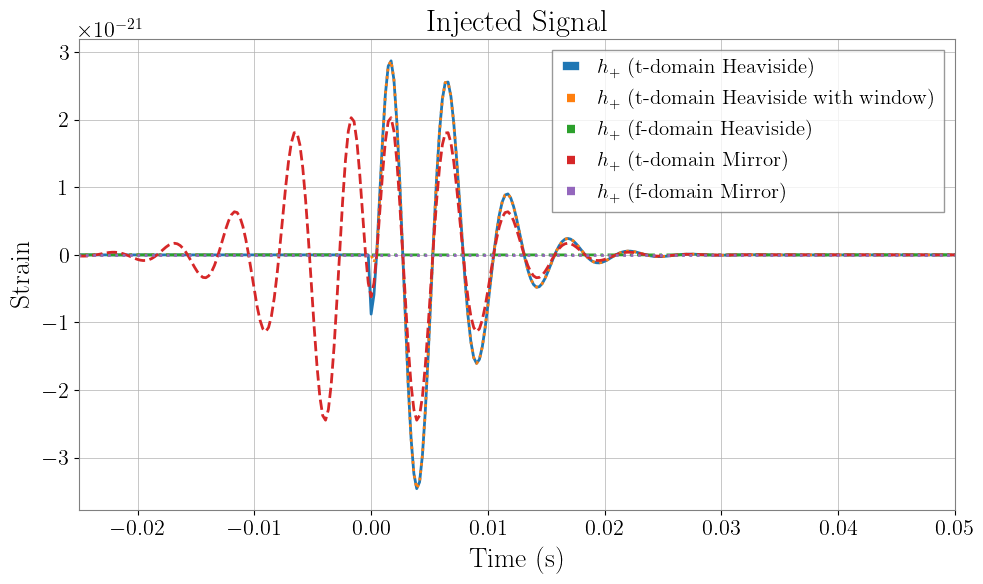

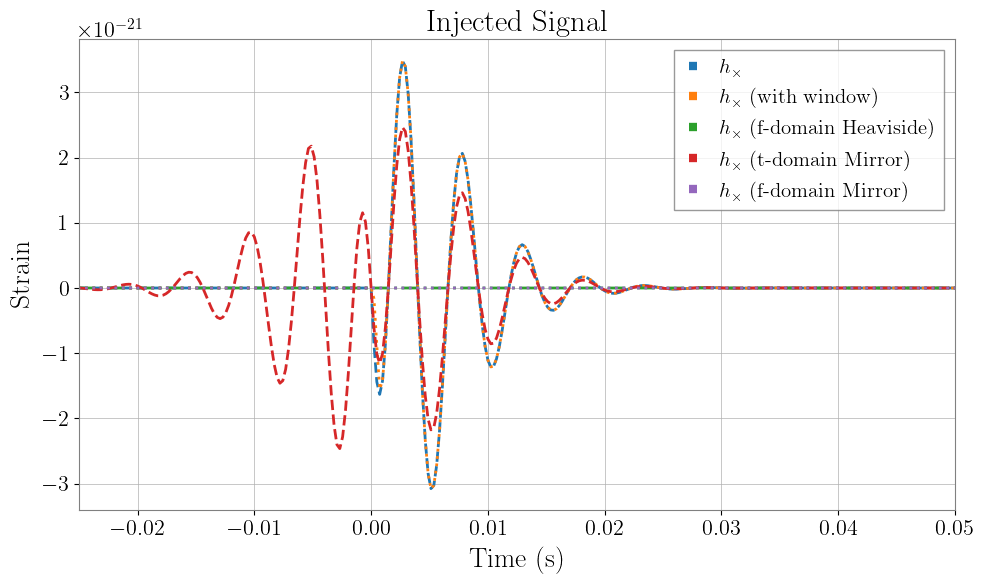

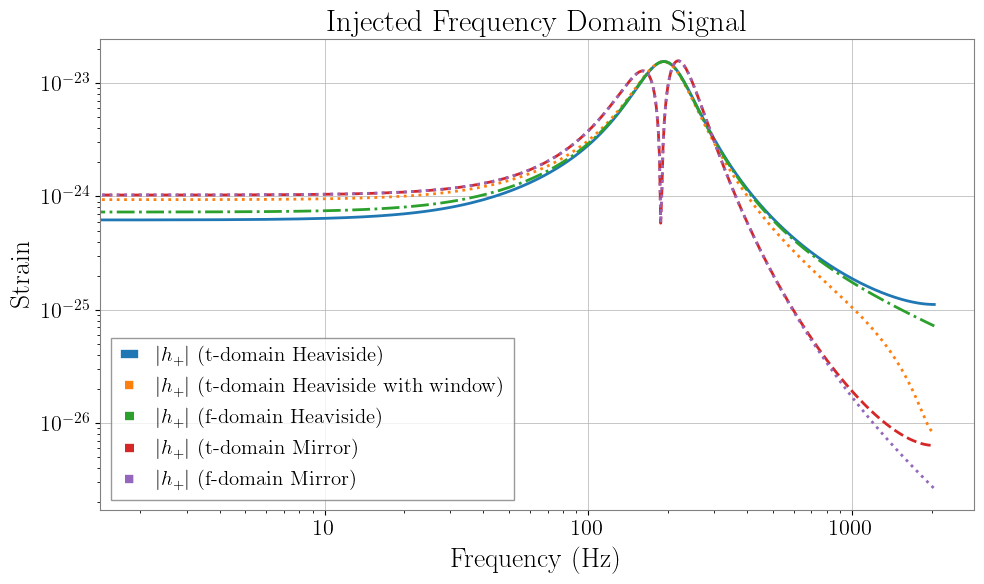

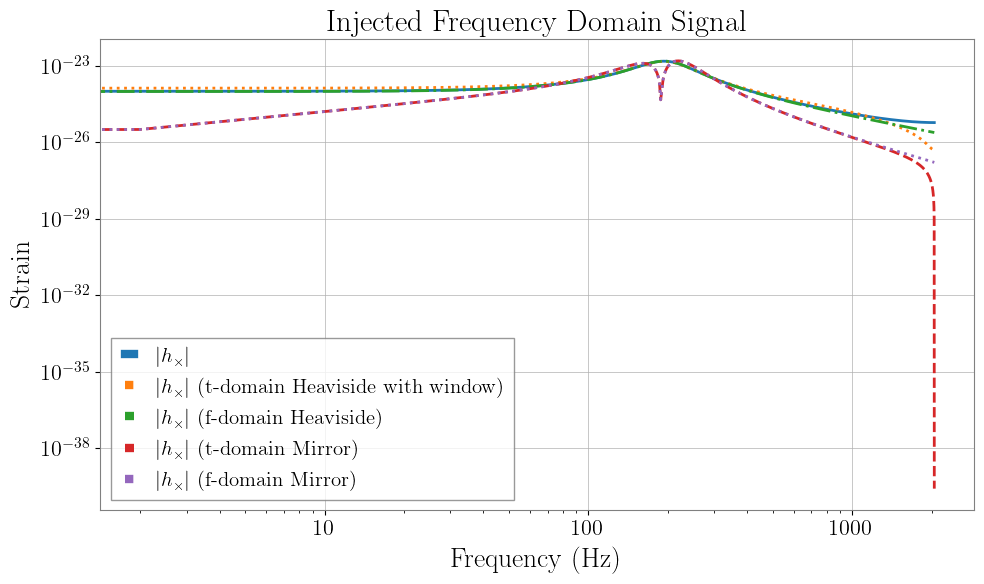

03:04 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.1, snr100, damped sinusoid parameterization
03:04 bilby INFO    : event_name : shiftRe_to_220_dw0.1w1_snr100_DSparam_v2
03:04 bilby INFO    : mode_number : two_mode
03:04 bilby INFO    : parameterization : DS
03:04 bilby INFO    : one_mode : False
03:04 bilby INFO    : analysis_one_mode : False
03:04 bilby INFO    : minimum_frequency : 20
03:04 bilby INFO    : maximum_frequency : 512
03:04 bilby INFO    : signal_roll_on_duration : 0.001
03:04 bilby INFO    : duration : 0.5
03:04 bilby INFO    : sampling frequency : 4096.0
03:04 bilby INFO    : trigger time : 0.0
03:04 bilby INFO    : start time : -0.25
03:04 bilby INFO    : A1 : 2.281200654005359
03:04 bilby INFO    : A2 : 2.193576170046821
03:04 bilby INFO    : alpha : 0.00029552945685847607
03:04 bilby INFO    : w1 : (1264.4143462793452+301.02689574732483j)
03:04 bilby INFO    : w2 : (1134.4389320257144+301.02689574732483j)
03:04 bilby INFO    : delta_w : (-129.97541

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1134.4389320257144 + i*301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

--------------------------------
SNR: [59.44020903527039, 70.47582006836025, 38.452110105294906]
network SNR: 99.89266457560461
--------------------------------
--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1134.4389320257144 + i*301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

-----------------------------

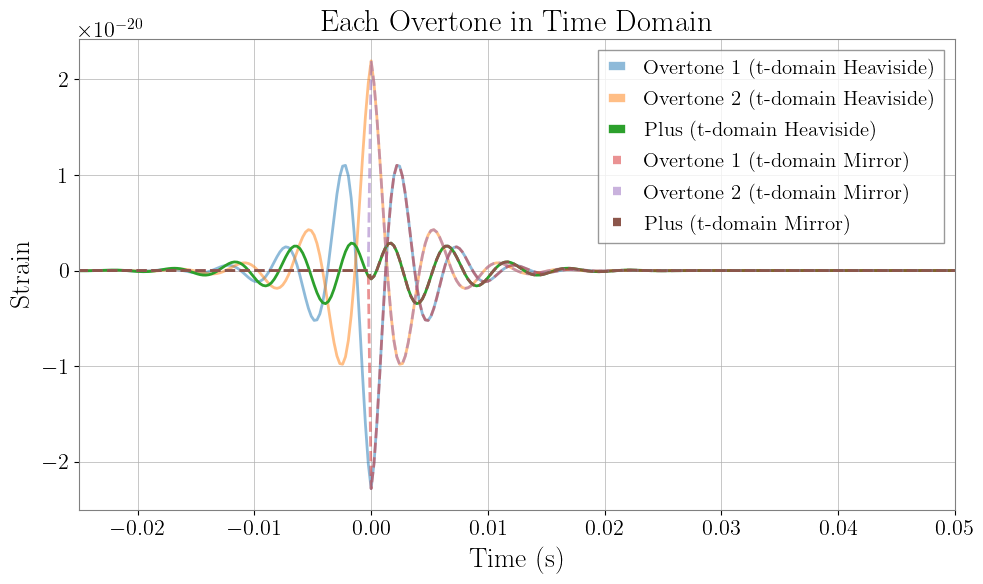

/Users/hayato/research/env/lib/python3.10/site-packages/numpy/fft/_pocketfft.py:70: ComplexWarning: Casting complex values to real discards the imaginary part
  r = pfi.execute(a, is_real, is_forward, fct)


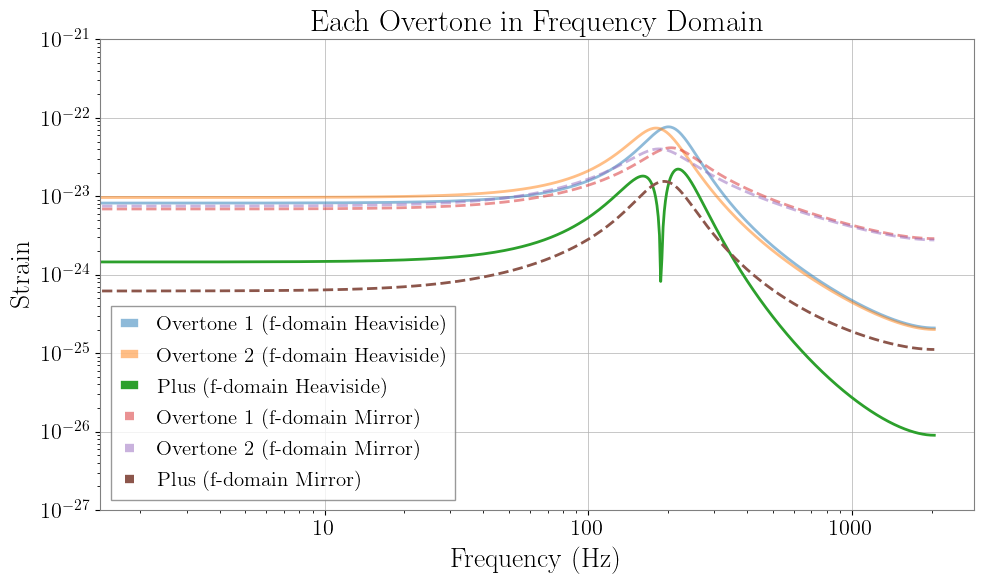

''

In [3]:
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_DSparam.ini'
config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_DSparam.ini'

# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam.ini'

waveform_generator_give_tdomain, injection_parameters_tdomain = get_ringdown_waveform_from_config(config_path, method='Heaviside', domain='t', get_each_overtone=False)
waveform_generator_give_tdomain_window, injection_parameters_window = get_ringdown_waveform_from_config(config_path, method='Window', domain='t', get_each_overtone=False)
waveform_generator_give_fdomain_Heaviside, injection_parameters_fdomain_Heaviside = get_ringdown_waveform_from_config(config_path, method='Heaviside', domain='f', get_each_overtone=False)
waveform_generator_give_tdomain_mirror, injection_parameters_tdomain_mirror = get_ringdown_waveform_from_config(config_path, method='Mirror', domain='t', get_each_overtone=False)
waveform_generator_give_fdomain_mirror, injection_parameters_fdomain_mirror = get_ringdown_waveform_from_config(config_path, method='Mirror', domain='f', get_each_overtone=False)

trigger_time = 0
duration = 0.5
sampling_frequency = 4096
plot_start = trigger_time - duration/20
plot_end = trigger_time + duration/10

"""plot waveform time domain"""
ht_plus_give_tdomain = waveform_generator_give_tdomain.time_domain_strain(injection_parameters_tdomain)['plus']
ht_cross_give_tdomain = waveform_generator_give_tdomain.time_domain_strain(injection_parameters_tdomain)['cross']
t_array_give_tdomain = waveform_generator_give_tdomain.time_array

ht_plus_give_tdomain_window = waveform_generator_give_tdomain_window.time_domain_strain(injection_parameters_window)['plus']
ht_cross_give_tdomain_window = waveform_generator_give_tdomain_window.time_domain_strain(injection_parameters_window)['cross']
t_array_give_tdomain_window = waveform_generator_give_tdomain_window.time_array

ht_plus_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.time_domain_strain(injection_parameters_fdomain_Heaviside)['plus']
ht_cross_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.time_domain_strain(injection_parameters_fdomain_Heaviside)['cross']
t_array_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.time_array

ht_plus_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.time_domain_strain(injection_parameters_tdomain_mirror)['plus']
ht_cross_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.time_domain_strain(injection_parameters_tdomain_mirror)['cross']
t_array_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.time_array

ht_plus_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.time_domain_strain(injection_parameters_fdomain_mirror)['plus']
ht_cross_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.time_domain_strain(injection_parameters_fdomain_mirror)['cross']
t_array_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.time_array

plt.figure()
plt.plot(t_array_give_tdomain, ht_plus_give_tdomain, label=r"$h_+$ (t-domain Heaviside)",)
plt.plot(t_array_give_tdomain_window, ht_plus_give_tdomain_window, label=r"$h_+$ (t-domain Heaviside with window)", ls=':')
plt.plot(t_array_give_fdomain_Heaviside, ht_plus_give_fdomain_Heaviside, label=r"$h_+$ (f-domain Heaviside)", ls='-.')
plt.plot(t_array_give_tdomain_mirror, ht_plus_give_tdomain_mirror, label=r"$h_+$ (t-domain Mirror)", ls='--')
plt.plot(t_array_give_fdomain_mirror, ht_plus_give_fdomain_mirror, label=r"$h_+$ (f-domain Mirror)", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t_array_give_tdomain, ht_cross_give_tdomain, label=r"$h_\times$", ls='--')
plt.plot(t_array_give_tdomain_window, ht_cross_give_tdomain_window, label=r"$h_\times$ (with window)", ls=':')
plt.plot(t_array_give_fdomain_Heaviside, ht_cross_give_fdomain_Heaviside, label=r"$h_\times$ (f-domain Heaviside)", ls='-.')
plt.plot(t_array_give_tdomain_mirror, ht_cross_give_tdomain_mirror, label=r"$h_\times$ (t-domain Mirror)", ls='--')
plt.plot(t_array_give_fdomain_mirror, ht_cross_give_fdomain_mirror, label=r"$h_\times$ (f-domain Mirror)", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid(True)
plt.show()
""""""

"""plot waveform frequency domain"""
hf_plus_give_tdomain = waveform_generator_give_tdomain.frequency_domain_strain(injection_parameters_tdomain)['plus']
hf_cross_give_tdomain = waveform_generator_give_tdomain.frequency_domain_strain(injection_parameters_tdomain)['cross']
f_array_give_tdomain = waveform_generator_give_tdomain.frequency_array

hf_plus_give_tdomain_window = waveform_generator_give_tdomain_window.frequency_domain_strain(injection_parameters_window)['plus']
hf_cross_give_tdomain_window = waveform_generator_give_tdomain_window.frequency_domain_strain(injection_parameters_window)['cross']
f_array_give_tdomain_window = waveform_generator_give_tdomain_window.frequency_array

hf_plus_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.frequency_domain_strain(injection_parameters_fdomain_Heaviside)['plus']
hf_cross_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.frequency_domain_strain(injection_parameters_fdomain_Heaviside)['cross']
f_array_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.frequency_array

hf_plus_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.frequency_domain_strain(injection_parameters_tdomain_mirror)['plus']
hf_cross_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.frequency_domain_strain(injection_parameters_tdomain_mirror)['cross']
f_array_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.frequency_array

hf_plus_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.frequency_domain_strain(injection_parameters_fdomain_mirror)['plus']
hf_cross_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.frequency_domain_strain(injection_parameters_fdomain_mirror)['cross']
f_array_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.frequency_array

plt.figure()
plt.plot(f_array_give_tdomain, np.abs(hf_plus_give_tdomain), label=r"$|h_+|$ (t-domain Heaviside)")
# plt.plot(f_array_give_tdomain, np.real(hf_plus_give_tdomain), label=r"$|h_+|$ (t-domain Heaviside)")
plt.plot(f_array_give_tdomain_window, np.abs(hf_plus_give_tdomain_window), label=r"$|h_+|$ (t-domain Heaviside with window)", ls=':')
# plt.plot(f_array_give_tdomain_window, np.real(hf_plus_give_tdomain_window), label=r"$|h_+|$ (t-domain Heaviside with window)", ls=':')
plt.plot(f_array_give_fdomain_Heaviside, np.abs(hf_plus_give_fdomain_Heaviside), label=r"$|h_+|$ (f-domain Heaviside)", ls='-.')
# plt.plot(f_array_give_fdomain_Heaviside, np.real(hf_plus_give_fdomain_Heaviside), label=r"$|h_+|$ (f-domain Heaviside)", ls='-.')
plt.plot(f_array_give_tdomain_mirror, np.abs(hf_plus_give_tdomain_mirror), label=r"$|h_+|$ (t-domain Mirror)", ls='--')
# plt.plot(f_array_give_tdomain_mirror, np.real(hf_plus_give_tdomain_mirror), label=r"$|h_+|$ (t-domain Mirror)", ls='--')
plt.plot(f_array_give_fdomain_mirror, np.abs(hf_plus_give_fdomain_mirror), label=r"$|h_+|$ (f-domain Mirror)", ls=':')
# plt.plot(f_array_give_fdomain_mirror, np.real(hf_plus_give_fdomain_mirror), label=r"$|h_+|$ (f-domain Mirror)", ls=':')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0, 200)
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(f_array_give_tdomain, np.abs(hf_cross_give_tdomain), label=r"$|h_\times|$", ls='-')
plt.plot(f_array_give_tdomain_window, np.abs(hf_cross_give_tdomain_window), label=r"$|h_\times|$ (t-domain Heaviside with window)", ls=':')
plt.plot(f_array_give_fdomain_Heaviside, np.abs(hf_cross_give_fdomain_Heaviside), label=r"$|h_\times|$ (f-domain Heaviside)", ls='-.')
plt.plot(f_array_give_tdomain_mirror, np.abs(hf_cross_give_tdomain_mirror), label=r"$|h_\times|$ (t-domain Mirror)", ls='--')
plt.plot(f_array_give_fdomain_mirror, np.abs(hf_cross_give_fdomain_mirror), label=r"$|h_\times|$ (f-domain Mirror)", ls=':')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0, 200)
plt.grid(True)
plt.legend()
plt.show()
""""""

"""plot each overtone in time domain"""
waveform_generator_each_overtone_Heaviside, injection_parameters_each_overtone_Heaviside = get_ringdown_waveform_from_config(config_path, method='Heaviside', domain='t', get_each_overtone=True)
waveform_generator_each_overtone_mirror, injection_parameters_each_overtone_mirror = get_ringdown_waveform_from_config(config_path, method='Mirror', domain='t', get_each_overtone=True)

overtone1_ht_give_Heaviside = waveform_generator_each_overtone_Heaviside.time_domain_strain(injection_parameters_each_overtone_Heaviside)['waveform1']
overtone2_ht_give_Heaviside = waveform_generator_each_overtone_Heaviside.time_domain_strain(injection_parameters_each_overtone_Heaviside)['waveform2']
plus_ht_give_Heaviside = waveform_generator_each_overtone_Heaviside.time_domain_strain(injection_parameters_each_overtone_Heaviside)['plus']
t_array_each_overtone_Heaviside = waveform_generator_each_overtone_Heaviside.time_array
overtone1_ht_give_mirror = waveform_generator_each_overtone_mirror.time_domain_strain(injection_parameters_each_overtone_mirror)['waveform1']
overtone2_ht_give_mirror = waveform_generator_each_overtone_mirror.time_domain_strain(injection_parameters_each_overtone_mirror)['waveform2']
plus_ht_give_mirror = waveform_generator_each_overtone_mirror.time_domain_strain(injection_parameters_each_overtone_mirror)['plus']
t_array_each_overtone_mirror = waveform_generator_each_overtone_mirror.time_array
plt.figure()
plt.plot(t_array_each_overtone_Heaviside, overtone1_ht_give_Heaviside.real, label=r"Overtone 1 (t-domain Heaviside)", alpha=0.5)
plt.plot(t_array_each_overtone_Heaviside, overtone2_ht_give_Heaviside.real, label=r"Overtone 2 (t-domain Heaviside)", alpha=0.5)
plt.plot(t_array_each_overtone_Heaviside, plus_ht_give_Heaviside.real, label=r"Plus (t-domain Heaviside)")
plt.plot(t_array_each_overtone_mirror, overtone1_ht_give_mirror.real, label=r"Overtone 1 (t-domain Mirror)", ls='--', alpha=0.5)
plt.plot(t_array_each_overtone_mirror, overtone2_ht_give_mirror.real, label=r"Overtone 2 (t-domain Mirror)", ls='--', alpha=0.5)
plt.plot(t_array_each_overtone_mirror, plus_ht_give_mirror.real, label=r"Plus (t-domain Mirror)", ls='--')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.xlim(plot_start, plot_end)
plt.title("Each Overtone in Time Domain")
plt.grid(True)
plt.show()
""""""

"""plot each overtone in frequency domain""" 
overtone1_hf_give_fdomain_Heaviside = waveform_generator_each_overtone_Heaviside.frequency_domain_strain(injection_parameters_each_overtone_Heaviside)['waveform1']
overtone2_hf_give_fdomain_Heaviside = waveform_generator_each_overtone_Heaviside.frequency_domain_strain(injection_parameters_each_overtone_Heaviside)['waveform2']
plus_hf_give_fdomain_Heaviside = waveform_generator_each_overtone_Heaviside.frequency_domain_strain(injection_parameters_each_overtone_Heaviside)['plus']
f_array_each_overtone_Heaviside = waveform_generator_each_overtone_Heaviside.frequency_array
overtone1_hf_give_fdomain_mirror = waveform_generator_each_overtone_mirror.frequency_domain_strain(injection_parameters_each_overtone_mirror)['waveform1']
overtone2_hf_give_fdomain_mirror = waveform_generator_each_overtone_mirror.frequency_domain_strain(injection_parameters_each_overtone_mirror)['waveform2']
plus_hf_give_fdomain_mirror = waveform_generator_each_overtone_mirror.frequency_domain_strain(injection_parameters_each_overtone_mirror)['plus']
f_array_each_overtone_mirror = waveform_generator_each_overtone_mirror.frequency_array
plt.figure()
plt.plot(f_array_each_overtone_Heaviside, np.abs(overtone1_hf_give_fdomain_Heaviside), label=r"Overtone 1 (f-domain Heaviside)", alpha=0.5)
plt.plot(f_array_each_overtone_Heaviside, np.abs(overtone2_hf_give_fdomain_Heaviside), label=r"Overtone 2 (f-domain Heaviside)", alpha=0.5)
plt.plot(f_array_each_overtone_Heaviside, np.abs(plus_hf_give_fdomain_Heaviside), label=r"Plus (f-domain Heaviside)")
plt.plot(f_array_each_overtone_mirror, np.abs(overtone1_hf_give_fdomain_mirror), label=r"Overtone 1 (f-domain Mirror)", ls='--', alpha=0.5)
plt.plot(f_array_each_overtone_mirror, np.abs(overtone2_hf_give_fdomain_mirror), label=r"Overtone 2 (f-domain Mirror)", ls='--', alpha=0.5)
plt.plot(f_array_each_overtone_mirror, np.abs(plus_hf_give_fdomain_mirror), label=r"Plus (f-domain Mirror)", ls='--')
plt.legend()
plt.xscale("log")
plt.yscale("log")
# plt.xlim(10, 1000)
plt.ylim(1e-27, 1e-21)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Each Overtone in Frequency Domain")
plt.grid(True)
plt.show()
""""""

03:50 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.1, snr100, overtone parameterization
03:50 bilby INFO    : event_name : shiftRe_to_220_dw0.1w1_snr100_OTparam_real_amp_f2_conditional
03:50 bilby INFO    : mode_number : two_mode
03:50 bilby INFO    : parameterization : OT_real_amp
03:50 bilby INFO    : one_mode : False
03:50 bilby INFO    : analysis_one_mode : False
03:50 bilby INFO    : minimum_frequency : 20
03:50 bilby INFO    : maximum_frequency : 512
03:50 bilby INFO    : signal_roll_on_duration : 0.001
03:50 bilby INFO    : duration : 0.5
03:50 bilby INFO    : sampling frequency : 4096.0
03:50 bilby INFO    : trigger time : 0.0
03:50 bilby INFO    : start time : -0.25
03:50 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: None
  time_domain_source_model: __main__.toy_model_of_two_QNMs_real_amp
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
03:50 bilby INFO    : Generation of mass paramete

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1134.4389320257144 + i*301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

--------------------------------
SNR: [59.44020903527039, 70.47582006836025, 38.452110105294906]
network SNR: 99.89266457560461
--------------------------------
--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1134.4389320257144 + i*301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

-----------------------------

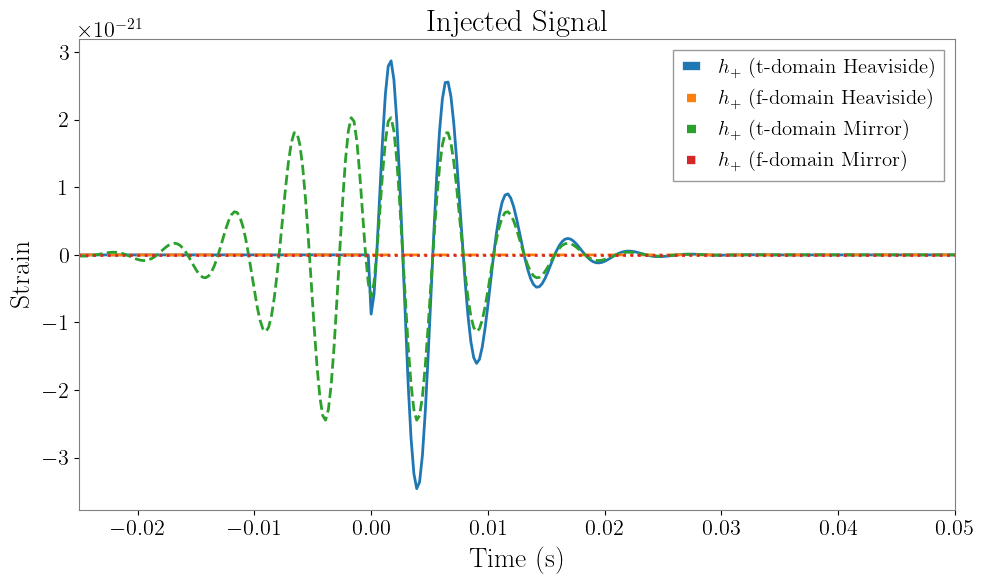

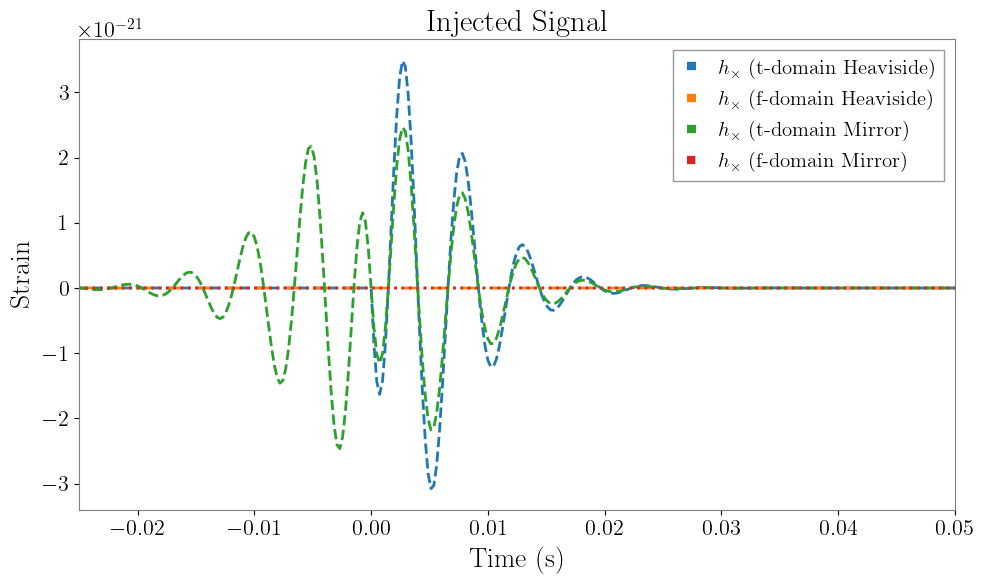

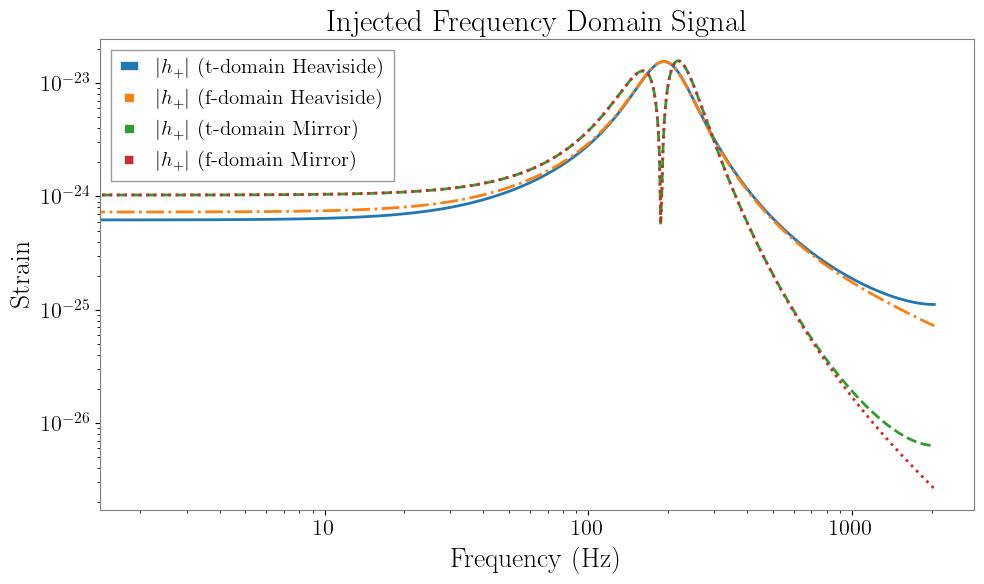

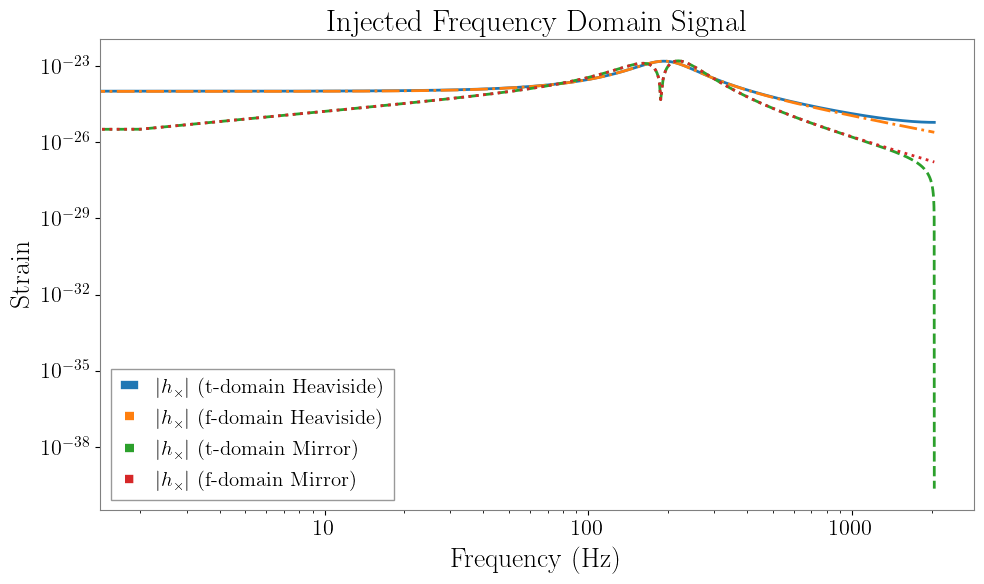

In [11]:
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_DSparam.ini'

# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam_real_amp.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam_real_amp.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam_real_amp.ini'
config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam_real_amp.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam_real_amp.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam_real_amp.ini'

waveform_generator_give_tdomain, injection_parameters_tdomain = get_ringdown_waveform_from_config(config_path, method='Heaviside', domain='t', get_each_overtone=False)
waveform_generator_give_fdomain_Heaviside, injection_parameters_fdomain_Heaviside = get_ringdown_waveform_from_config(config_path, method='Heaviside', domain='f', get_each_overtone=False)

waveform_generator_give_tdomain_mirror, injection_parameters_tdomain_mirror = get_ringdown_waveform_from_config(config_path, method='Mirror', domain='t', get_each_overtone=False)
waveform_generator_give_fdomain_mirror, injection_parameters_fdomain_mirror = get_ringdown_waveform_from_config(config_path, method='Mirror', domain='f', get_each_overtone=False)

trigger_time = 0
duration = 0.5
sampling_frequency = 4096
plot_start = trigger_time - duration/20
plot_end = trigger_time + duration/10

ht_plus_give_tdomain = waveform_generator_give_tdomain.time_domain_strain(injection_parameters_tdomain)['plus']
ht_cross_give_tdomain_Heaviside = waveform_generator_give_tdomain.time_domain_strain(injection_parameters_tdomain)['cross']
t_array_give_tdomain = waveform_generator_give_tdomain.time_array
ht_plus_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.time_domain_strain(injection_parameters_fdomain_Heaviside)['plus']
ht_cross_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.time_domain_strain(injection_parameters_fdomain_Heaviside)['cross']
t_array_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.time_array

ht_plus_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.time_domain_strain(injection_parameters_tdomain_mirror)['plus']
ht_cross_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.time_domain_strain(injection_parameters_tdomain_mirror)['cross']
t_array_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.time_array
ht_plus_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.time_domain_strain(injection_parameters_fdomain_mirror)['plus']
ht_cross_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.time_domain_strain(injection_parameters_fdomain_mirror)['cross']
t_array_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.time_array

plt.figure()
plt.plot(t_array_give_tdomain, ht_plus_give_tdomain, label=r"$h_+$ (t-domain Heaviside)",)
plt.plot(t_array_give_fdomain_Heaviside, ht_plus_give_fdomain_Heaviside, label=r"$h_+$ (f-domain Heaviside)", ls='-.')
plt.plot(t_array_give_tdomain_mirror, ht_plus_give_tdomain_mirror, label=r"$h_+$ (t-domain Mirror)", ls='--')
plt.plot(t_array_give_fdomain_mirror, ht_plus_give_fdomain_mirror, label=r"$h_+$ (f-domain Mirror)", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_array_give_tdomain, ht_cross_give_tdomain, label=r"$h_\times$ (t-domain Heaviside)", ls='--')
plt.plot(t_array_give_fdomain_Heaviside, ht_cross_give_fdomain_Heaviside, label=r"$h_\times$ (f-domain Heaviside)", ls='-.')
plt.plot(t_array_give_tdomain_mirror, ht_cross_give_tdomain_mirror, label=r"$h_\times$ (t-domain Mirror)", ls='--')
plt.plot(t_array_give_fdomain_mirror, ht_cross_give_fdomain_mirror, label=r"$h_\times$ (f-domain Mirror)", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid()
plt.show()

hf_plus_give_tdomain = waveform_generator_give_tdomain.frequency_domain_strain(injection_parameters_tdomain)['plus']
hf_cross_give_tdomain = waveform_generator_give_tdomain.frequency_domain_strain(injection_parameters_tdomain)['cross']
f_array_give_tdomain = waveform_generator_give_tdomain.frequency_array
hf_plus_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.frequency_domain_strain(injection_parameters_fdomain_Heaviside)['plus']
hf_cross_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.frequency_domain_strain(injection_parameters_fdomain_Heaviside)['cross']
f_array_give_fdomain_Heaviside = waveform_generator_give_fdomain_Heaviside.frequency_array

hf_plus_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.frequency_domain_strain(injection_parameters_tdomain_mirror)['plus']
hf_cross_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.frequency_domain_strain(injection_parameters_tdomain_mirror)['cross']
f_array_give_tdomain_mirror = waveform_generator_give_tdomain_mirror.frequency_array
hf_plus_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.frequency_domain_strain(injection_parameters_fdomain_mirror)['plus']
hf_cross_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.frequency_domain_strain(injection_parameters_fdomain_mirror)['cross']
f_array_give_fdomain_mirror = waveform_generator_give_fdomain_mirror.frequency_array

plt.figure()
plt.plot(f_array_give_tdomain, np.abs(hf_plus_give_tdomain), label=r"$|h_+|$ (t-domain Heaviside)")
plt.plot(f_array_give_fdomain_Heaviside, np.abs(hf_plus_give_fdomain_Heaviside), label=r"$|h_+|$ (f-domain Heaviside)", ls='-.')
plt.plot(f_array_give_tdomain_mirror, np.abs(hf_plus_give_tdomain_mirror), label=r"$|h_+|$ (t-domain Mirror)", ls='--')
plt.plot(f_array_give_fdomain_mirror, np.abs(hf_plus_give_fdomain_mirror), label=r"$|h_+|$ (f-domain Mirror)", ls=':')
# plt.plot(f_array_give_tdomain, np.real(hf_plus_give_tdomain), label=r"$| h_+|$ (t-domain Heaviside)")
# plt.plot(f_array_give_fdomain_Heaviside, np.real(hf_plus_give_fdomain_Heaviside), label=r"$|  h_+|$ (f-domain Heaviside)", ls='-.')
# plt.plot(f_array_give_tdomain_mirror, np.real(hf_plus_give_tdomain_mirror), label=r"$| h_+|$ (t-domain Mirror)", ls='--')
# plt.plot(f_array_give_fdomain_mirror, np.real(hf_plus_give_fdomain_mirror), label=r"$| h_+|$ (f-domain Mirror)", ls=':')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0, 200)
plt.grid()
plt.legend()
plt.show()

plt.figure()
plt.plot(f_array_give_tdomain, np.abs(hf_cross_give_tdomain), label=r"$|h_\times|$ (t-domain Heaviside)", ls='-')
plt.plot(f_array_give_fdomain_Heaviside, np.abs(hf_cross_give_fdomain_Heaviside), label=r"$|h_\times|$ (f-domain Heaviside)", ls='-.')
plt.plot(f_array_give_tdomain_mirror, np.abs(hf_cross_give_tdomain_mirror), label=r"$|h_\times|$ (t-domain Mirror)", ls='--')
plt.plot(f_array_give_fdomain_mirror, np.abs(hf_cross_give_fdomain_mirror), label=r"$|h_\times|$ (f-domain Mirror)", ls=':')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")   
# plt.xlim(0, 200)
plt.grid()
plt.legend()
plt.show()

09:10 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.01, snr100, damped sinusoid parameterization
09:10 bilby INFO    : event_name : shiftRe_to_220_dw0.01w1_snr100_DSparam
09:10 bilby INFO    : mode_number : two_mode
09:10 bilby INFO    : parameterization : DS
09:10 bilby INFO    : one_mode : False
09:10 bilby INFO    : analysis_one_mode : False
09:10 bilby INFO    : minimum_frequency : 20
09:10 bilby INFO    : maximum_frequency : 512
09:10 bilby INFO    : signal_roll_on_duration : 0.001
09:10 bilby INFO    : duration : 0.5
09:10 bilby INFO    : sampling frequency : 4096.0
09:10 bilby INFO    : trigger time : 0.0
09:10 bilby INFO    : start time : -0.25
09:10 bilby INFO    : A1 : 21.69641094197332
09:10 bilby INFO    : A2 : 21.61307163513923
09:10 bilby INFO    : alpha : 0.00029552945685847607
09:10 bilby INFO    : w1 : (1264.4143462793452+301.02689574732483j)
09:10 bilby INFO    : w2 : (1251.416804853982+301.02689574732483j)
09:10 bilby INFO    : delta_w : (-12.99754142

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1251.416804853982 + i*301.02689574732483
delta_w = w2 - w1 = -12.997541425363124 + i*0.0
Re[delta_w] / Re[w1] = -0.010279495375554365
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 12.997541425363124
|delta_w| / |w1| = 0.01000000000000003
A / |delta_w| = 21.69641094197332
--------------------------------

--------------------------------
SNR: [59.44882353091659, 70.39522643743567, 39.11633832117552]
network SNR: 100.09864358743613
--------------------------------


09:10 bilby INFO    :   matched filter SNR = 39.12-0.00j
09:10 bilby INFO    :   A = 0.28200000000000003
09:10 bilby INFO    :   alpha = 0.00029552945685847607
09:10 bilby INFO    :   f1 = 201.23779332666524
09:10 bilby INFO    :   f2 = 199.16917036077703
09:10 bilby INFO    :   tau1 = 0.0033219623034593474
09:10 bilby INFO    :   tau2 = 0.0033219623034593474
09:10 bilby INFO    :   phi1 = -3.141592653589793
09:10 bilby INFO    :   phi2 = 0.0
09:10 bilby INFO    :   ra = 0.0
09:10 bilby INFO    :   dec = 0.0
09:10 bilby INFO    :   psi = 0.0
09:10 bilby INFO    :   geocent_time = 0.0
09:10 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.01, snr100, overtone parameterization
09:10 bilby INFO    : event_name : shiftRe_to_220_dw0.01w1_snr100_OTparam_f2_conditional
09:10 bilby INFO    : mode_number : two_mode
09:10 bilby INFO    : parameterization : OT_Mirror
09:10 bilby INFO    : one_mode : False
09:10 bilby INFO    : analysis_one_mode : False
09:10 bilby INFO    : minimum_f

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1251.416804853982 + i*301.02689574732483
delta_w = w2 - w1 = -12.997541425363124 + i*0.0
Re[delta_w] / Re[w1] = -0.010279495375554365
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 12.997541425363124
|delta_w| / |w1| = 0.01000000000000003
A / |delta_w| = 21.69641094197332
--------------------------------

--------------------------------
SNR: [59.4488235309167, 70.3952264374358, 39.1163383211756]
network SNR: 100.09864358743631
--------------------------------
--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1251.416804853982 + i*301.02689574732483
delta_w = w2 - w1 = -12.997541425363124 + i*0.0
Re[delta_w] / Re[w1] = -0.010279495375554365
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 12.997541425363124
|delta_w| / |w1| = 0.01000000000000003
A / |delta_w| = 21.69641094197332
--------------------------------

----------------------------

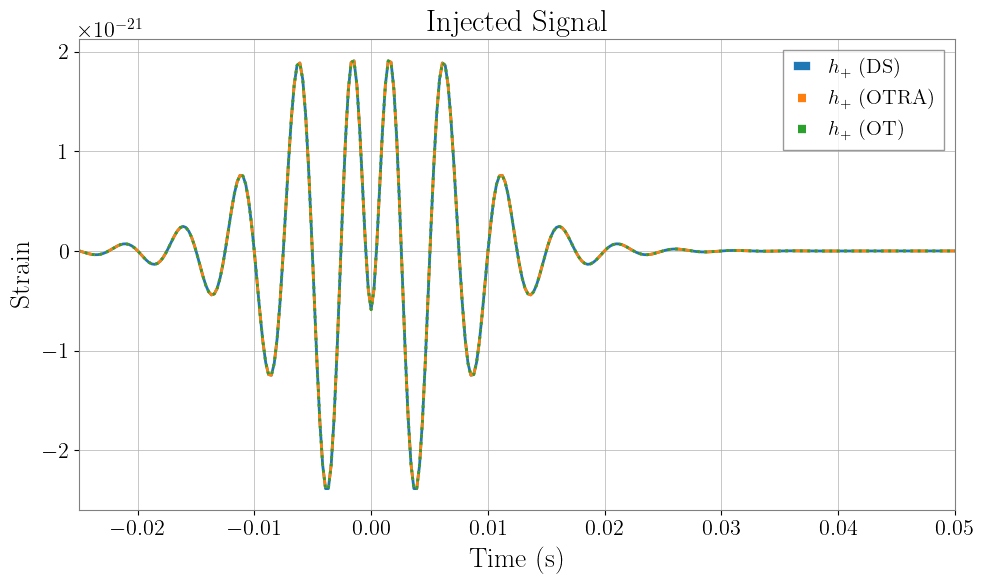

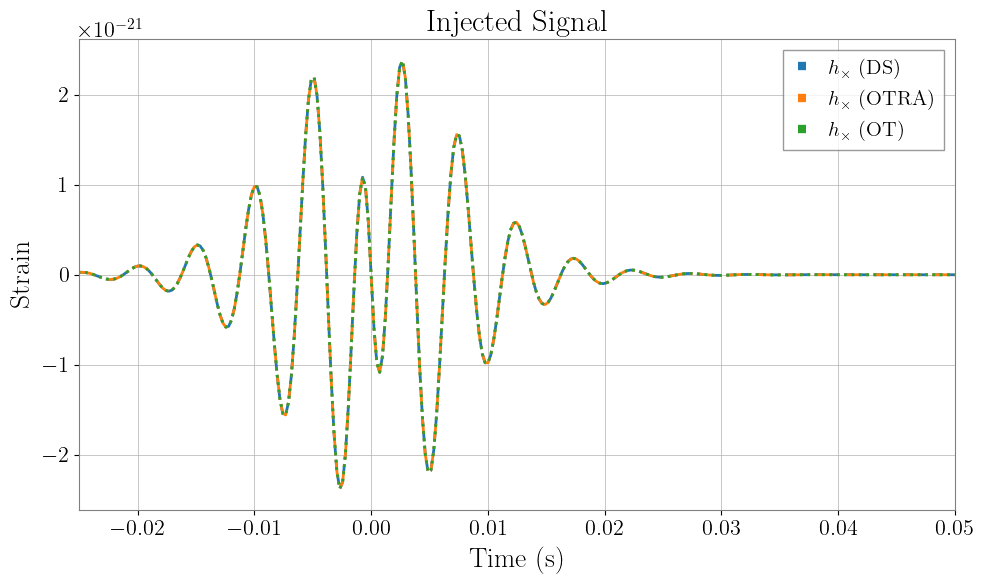

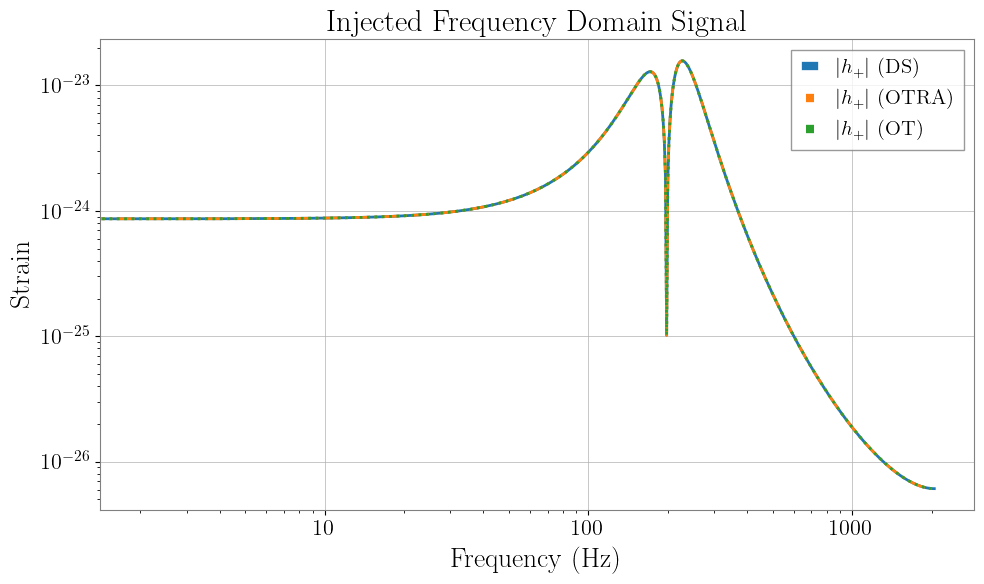

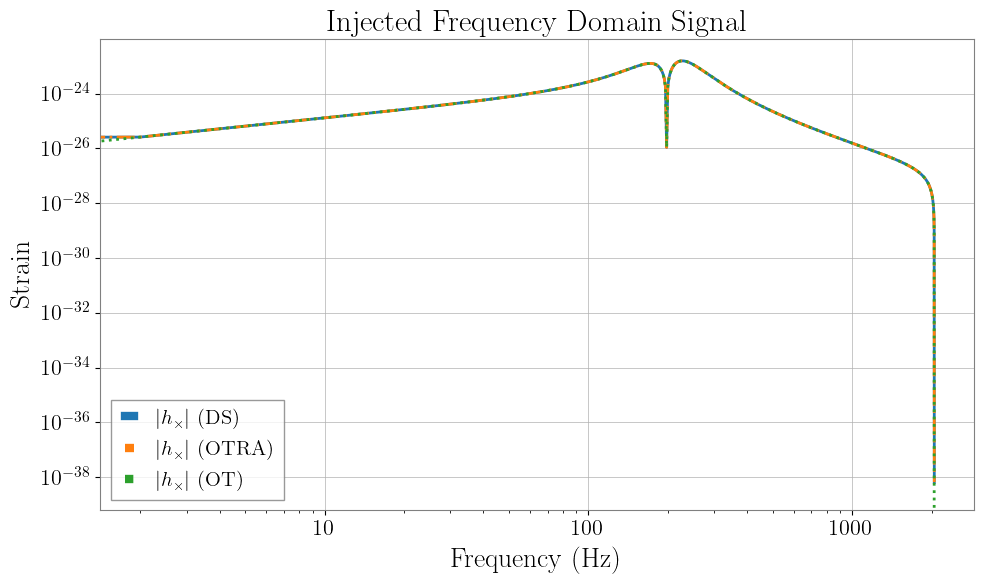

In [16]:
config_path_DS_list = [
                    '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_DSparam.ini',
                    '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_DSparam.ini',
                    '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_DSparam.ini',
                    '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_DSparam.ini',
                    '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_DSparam.ini',
                    '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_DSparam.ini'
                    ]

config_path_OTRA_list = [
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam_real_amp.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam_real_amp.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam_real_amp.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam_real_amp.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam_real_amp.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam_real_amp.ini']
config_path_OT_list = [
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam_mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam_mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam_mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam_mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam_mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam_mirror.ini'
                        ]

index = 4
waveform_generator_DS, injection_parameters_DS = get_ringdown_waveform_from_config(config_path_DS_list[index], method='Mirror', domain='t', get_each_overtone=False)
waveform_generator_OTRA, injection_parameters_OTRA = get_ringdown_waveform_from_config(config_path_OTRA_list[index], method='Mirror', domain='t', get_each_overtone=False)
waveform_generator_OT, injection_parameters_OT = get_ringdown_waveform_from_config(config_path_OT_list[index], method='Mirror', domain='t', get_each_overtone=False)

trigger_time = 0
duration = 0.5
sampling_frequency = 4096
plot_start = trigger_time - duration/20
plot_end = trigger_time + duration/10

ht_plus_DS = waveform_generator_DS.time_domain_strain(injection_parameters_DS)['plus']
ht_cross_DS = waveform_generator_DS.time_domain_strain(injection_parameters_DS)['cross']
t_array_DS = waveform_generator_DS.time_array
ht_plus_OTRA = waveform_generator_OTRA.time_domain_strain(injection_parameters_OTRA)['plus']
ht_cross_OTRA = waveform_generator_OTRA.time_domain_strain(injection_parameters_OTRA)['cross']
t_array_OTRA = waveform_generator_OTRA.time_array
ht_plus_OT = waveform_generator_OT.time_domain_strain(injection_parameters_OT)['plus']
ht_cross_OT = waveform_generator_OT.time_domain_strain(injection_parameters_OT)['cross']
t_array_OT = waveform_generator_OT.time_array

plt.figure()
plt.plot(t_array_DS, ht_plus_DS, label=r"$h_+$ (DS)",)
plt.plot(t_array_OTRA, ht_plus_OTRA, label=r"$h_+$ (OTRA)", ls='-.')
plt.plot(t_array_OT, ht_plus_OT, label=r"$h_+$ (OT)", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t_array_DS, ht_cross_DS, label=r"$h_\times$ (DS)", ls='--')
plt.plot(t_array_OTRA, ht_cross_OTRA, label=r"$h_\times$ (OTRA)", ls='-.')
plt.plot(t_array_OT, ht_cross_OT, label=r"$h_\times$ (OT)", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid(True)
plt.show()

hf_plus_DS = waveform_generator_DS.frequency_domain_strain(injection_parameters_DS)['plus']
hf_cross_DS = waveform_generator_DS.frequency_domain_strain(injection_parameters_DS)['cross']
f_array_DS = waveform_generator_DS.frequency_array
hf_plus_OTRA = waveform_generator_OTRA.frequency_domain_strain(injection_parameters_OTRA)['plus']
hf_cross_OTRA = waveform_generator_OTRA.frequency_domain_strain(injection_parameters_OTRA)['cross']
f_array_OTRA = waveform_generator_OTRA.frequency_array
hf_plus_OT = waveform_generator_OT.frequency_domain_strain(injection_parameters_OT)['plus']
hf_cross_OT = waveform_generator_OT.frequency_domain_strain(injection_parameters_OT)['cross']
f_array_OT = waveform_generator_OT.frequency_array

plt.figure()
plt.plot(f_array_DS, np.abs(hf_plus_DS), label=r"$|h_+|$ (DS)")
plt.plot(f_array_OTRA, np.abs(hf_plus_OTRA), label=r"$|h_+|$ (OTRA)", ls='-.')
plt.plot(f_array_OT, np.abs(hf_plus_OT), label=r"$|h_+|$ (OT)", ls=':')
# plt.plot(f_array_give_tdomain, np.real(hf_plus_give_tdomain), label=r"$| h_+|$ (t-domain Heaviside)")
# plt.plot(f_array_give_fdomain_Heaviside, np.real(hf_plus_give_fdomain_Heaviside), label=r"$|  h_+|$ (f-domain Heaviside)", ls='-.')
# plt.plot(f_array_give_tdomain_mirror, np.real(hf_plus_give_tdomain_mirror), label=r"$| h_+|$ (t-domain Mirror)", ls='--')
# plt.plot(f_array_give_fdomain_mirror, np.real(hf_plus_give_fdomain_mirror), label=r"$| h_+|$ (f-domain Mirror)", ls=':')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0, 200)
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(f_array_DS, np.abs(hf_cross_DS), label=r"$|h_\times|$ (DS)", ls='-')
plt.plot(f_array_OTRA, np.abs(hf_cross_OTRA), label=r"$|h_\times|$ (OTRA)", ls='-.')
plt.plot(f_array_OT, np.abs(hf_cross_OT), label=r"$|h_\times|$ (OT)", ls=':')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0, 200)
plt.grid(True)
plt.legend()
plt.show()

11:19 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.001, snr100, overtone parameterization
11:19 bilby INFO    : event_name : shiftRe_to_220_dw0.001w1_snr100_OTparam_Mirror
11:19 bilby INFO    : mode_number : two_mode
11:19 bilby INFO    : parameterization : OT_Mirror
11:19 bilby INFO    : one_mode : False
11:19 bilby INFO    : analysis_one_mode : False
11:19 bilby INFO    : minimum_frequency : 20
11:19 bilby INFO    : maximum_frequency : 512
11:19 bilby INFO    : signal_roll_on_duration : 0.001
11:19 bilby INFO    : duration : 0.5
11:19 bilby INFO    : sampling frequency : 4096.0
11:19 bilby INFO    : trigger time : 0.0
11:19 bilby INFO    : start time : -0.25
11:19 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: None
  time_domain_source_model: __main__.toy_model_of_two_QNMs_Mirror
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
11:19 bilby INFO    : Generation of mass parameters failed with me

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1263.114592136809 + i*301.02689574732483
delta_w = w2 - w1 = -1.2997541425361305 + i*0.0
Re[delta_w] / Re[w1] = -0.0010279495375552926
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 1.2997541425361305
|delta_w| / |w1| = 0.000999999999999863
A / |delta_w| = 216.1947331452254
--------------------------------

--------------------------------
SNR: [59.402997072498835, 70.34059800264426, 39.11332706901312]
network SNR: 100.03183564732029
--------------------------------
--------------------------------
SNR: [59.1664906079096, 70.38160434658762, 37.95032299344464]
network SNR: 99.47095483889872
--------------------------------


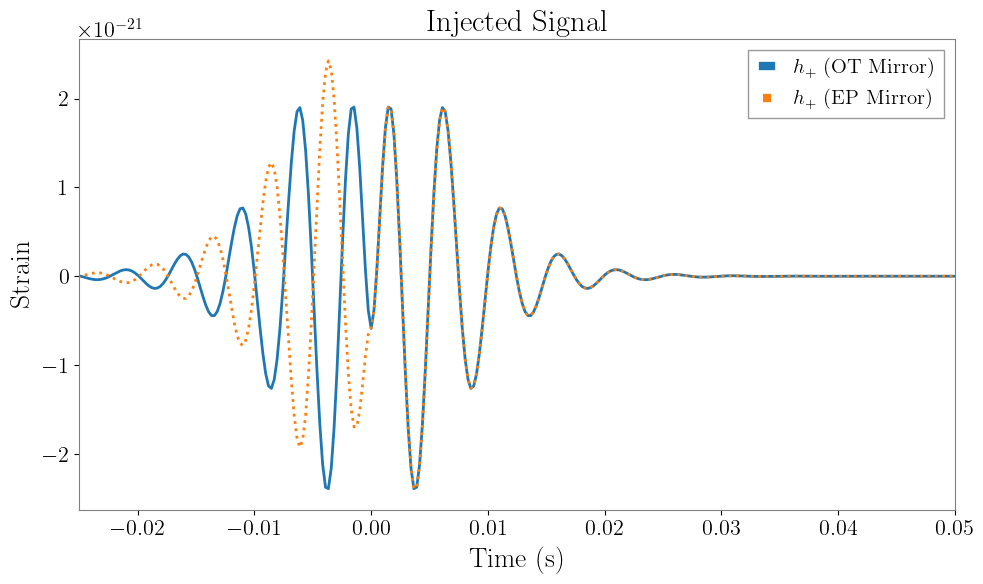

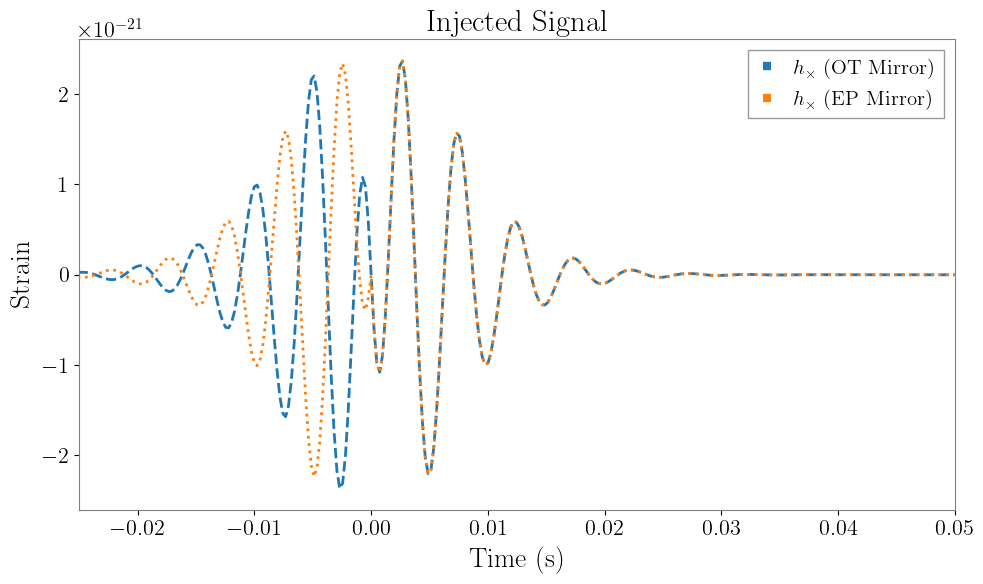

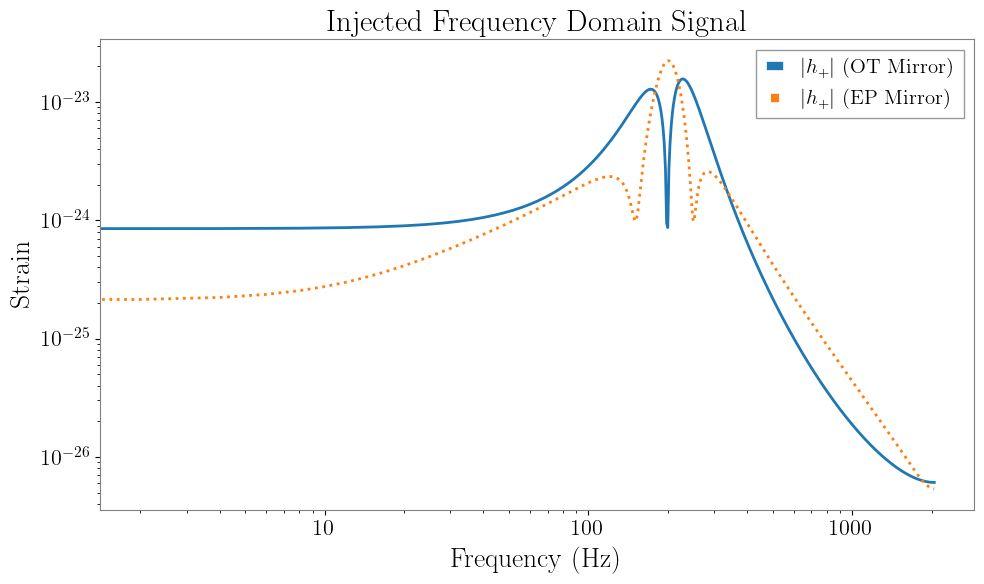

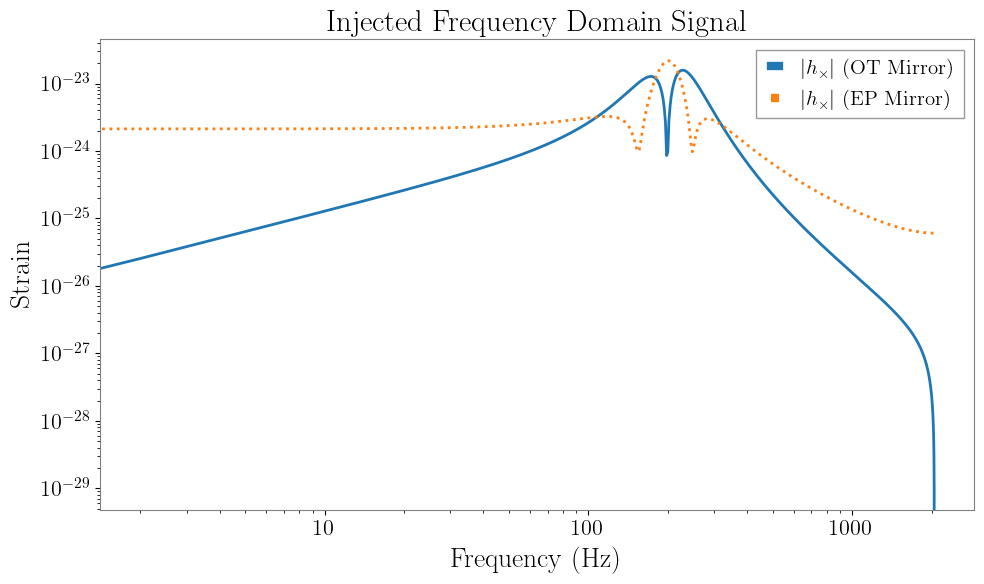

''

In [33]:
config_path_OT_list = [
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam_Mirror.ini'
                        ]

config_path_EP_list = [
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_EPparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_EPparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_EPparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_EPparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_EPparam_Mirror.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_EPparam_Mirror.ini'
                        ]
index = 5
method = 'Mirror'
waveform_generator_OT_mirror, injection_parameters_OT_mirror = get_ringdown_waveform_from_config(config_path_OT_list[index], method=method, domain='t', get_each_overtone=False)
waveform_generator_EP_mirror, injection_parameters_EP_mirror = get_ringdown_waveform_from_config(config_path_EP_list[index], method=method, domain='t', get_each_overtone=False)

trigger_time = 0
duration = 0.5
sampling_frequency = 4096
plot_start = trigger_time - duration/20
plot_end = trigger_time + duration/10

"""plot waveform time domain"""
ht_plus_OT_mirror = waveform_generator_OT_mirror.time_domain_strain(injection_parameters_OT_mirror)['plus']
ht_cross_OT_mirror = waveform_generator_OT_mirror.time_domain_strain(injection_parameters_OT_mirror)['cross']
t_array_OT_mirror = waveform_generator_OT_mirror.time_array

ht_plus_EP_mirror = waveform_generator_EP_mirror.time_domain_strain(injection_parameters_EP_mirror)['plus']
ht_cross_EP_mirror = waveform_generator_EP_mirror.time_domain_strain(injection_parameters_EP_mirror)['cross']
t_array_EP_mirror = waveform_generator_EP_mirror.time_array

plt.figure()
plt.plot(t_array_OT_mirror, ht_plus_OT_mirror, label=rf"$h_+$ (OT {method})",)
plt.plot(t_array_EP_mirror, ht_plus_EP_mirror, label=rf"$h_+$ (EP {method})", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_array_OT_mirror, ht_cross_OT_mirror, label=rf"$h_\times$ (OT {method})", ls='--')
plt.plot(t_array_EP_mirror, ht_cross_EP_mirror, label=rf"$h_\times$ (EP {method})", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid()
plt.show()
""""""

"""plot waveform frequency domain"""
hf_plus_OT_mirror = waveform_generator_OT_mirror.frequency_domain_strain(injection_parameters_OT_mirror)['plus']
hf_cross_OT_mirror = waveform_generator_OT_mirror.frequency_domain_strain(injection_parameters_OT_mirror)['cross']
f_array_OT_mirror = waveform_generator_OT_mirror.frequency_array

hf_plus_EP_mirror = waveform_generator_EP_mirror.frequency_domain_strain(injection_parameters_EP_mirror)['plus']
hf_cross_EP_mirror = waveform_generator_EP_mirror.frequency_domain_strain(injection_parameters_EP_mirror)['cross']
f_array_EP_mirror = waveform_generator_EP_mirror.frequency_array

plt.figure()
plt.plot(f_array_OT_mirror, np.abs(hf_plus_OT_mirror), label=rf"$|h_+|$ (OT {method})", ls='-')
# plt.plot(f_array_OT_mirror, np.real(hf_plus_OT_mirror), label=r"$|h_+|$ (OT Mirror)")
plt.plot(f_array_EP_mirror, np.abs(hf_plus_EP_mirror), label=rf"$|h_+|$ (EP {method})", ls=':')
# plt.plot(f_array_EP_mirror, np.real(hf_plus_EP_mirror), label=r"$|h_+|$ (EP Mirror)", ls=':')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0, 200)
plt.grid()
plt.legend()
plt.show()

plt.figure()
plt.plot(f_array_OT_mirror, np.abs(hf_cross_OT_mirror), label=rf"$|h_\times|$ (OT {method})", ls='-')
plt.plot(f_array_EP_mirror, np.abs(hf_cross_EP_mirror), label=rf"$|h_\times|$ (EP {method})", ls=':')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0, 200)
plt.grid()
plt.legend()
plt.show()
""""""

09:25 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.1, snr100, overtone parameterization
09:25 bilby INFO    : event_name : shiftRe_to_220_dw0.1w1_snr100_OTparam_Heaviside
09:25 bilby INFO    : mode_number : two_mode
09:25 bilby INFO    : parameterization : OT_Heaviside
09:25 bilby INFO    : one_mode : False
09:25 bilby INFO    : analysis_one_mode : False
09:25 bilby INFO    : minimum_frequency : 20
09:25 bilby INFO    : maximum_frequency : 512
09:25 bilby INFO    : signal_roll_on_duration : 0.001
09:25 bilby INFO    : duration : 0.5
09:25 bilby INFO    : sampling frequency : 4096.0
09:25 bilby INFO    : trigger time : 0.0
09:25 bilby INFO    : start time : -0.25
09:25 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: None
  time_domain_source_model: __main__.toy_model_of_two_QNMs_Heaviside
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
09:25 bilby INFO    : Generation of mass parameters failed wi

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1134.4389320257144 + i*301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

--------------------------------
SNR: [59.44020903527037, 70.47582006836024, 38.4521101052949]
network SNR: 99.89266457560458
--------------------------------
--------------------------------
SNR: [61.245466077969105, 72.63654641323696, 39.25676456389022]
network SNR: 102.80159801274831
--------------------------------


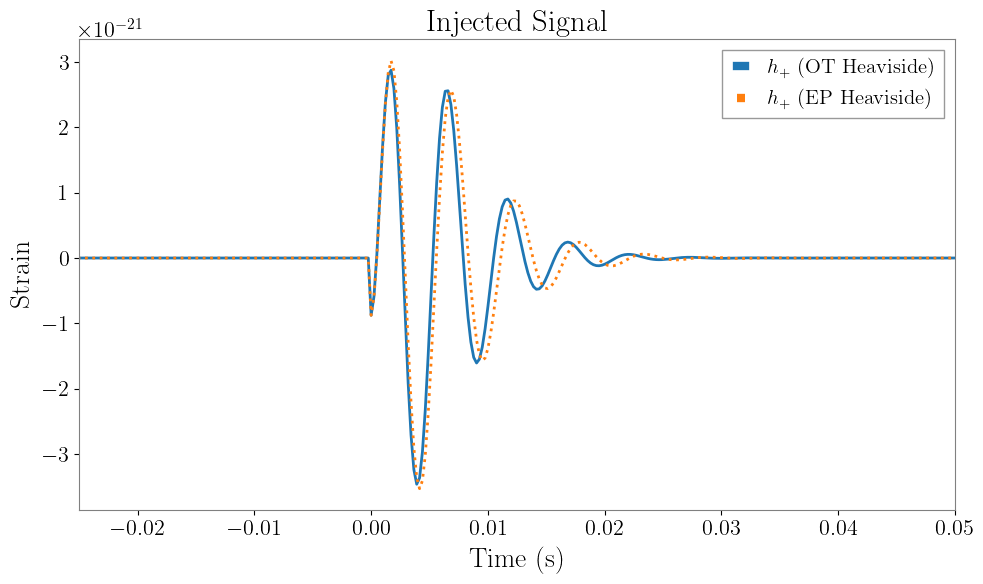

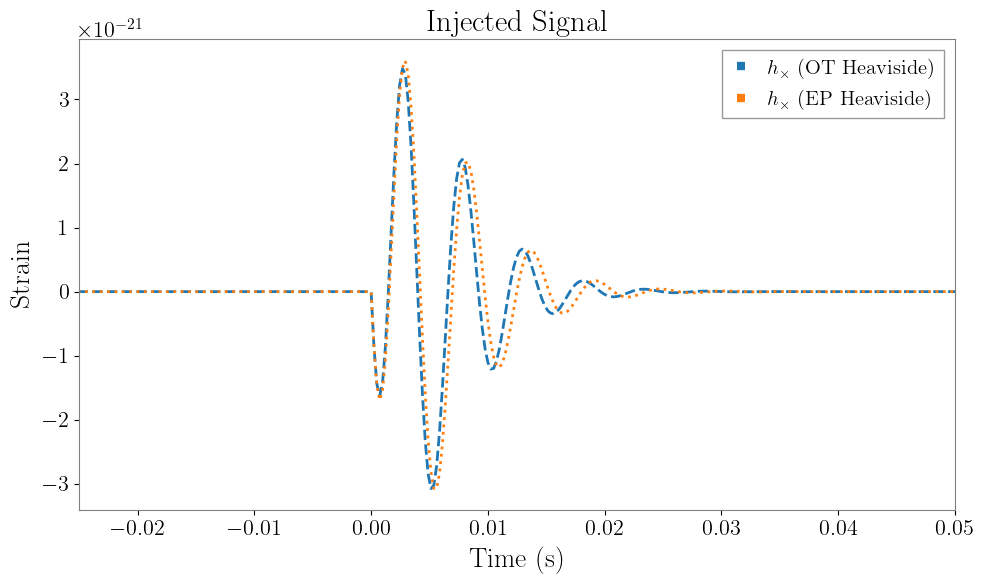

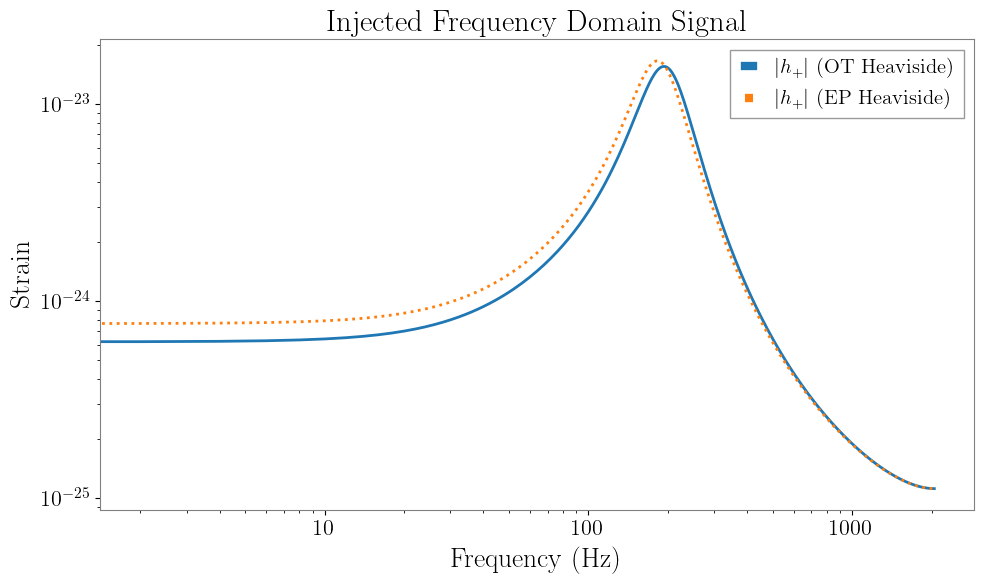

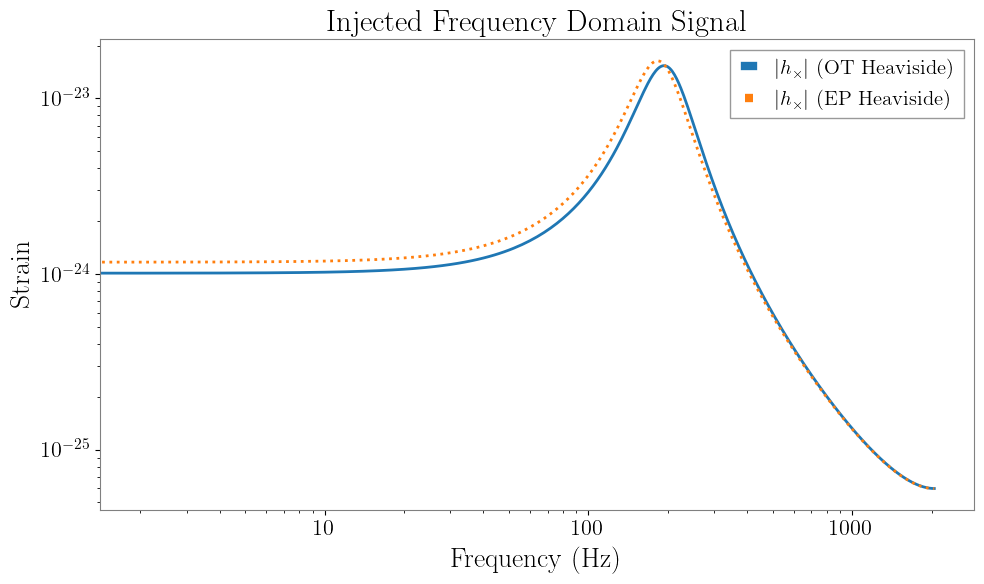

''

In [29]:
config_path_OT_list = [
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam_Heaviside.ini'
                        ]

config_path_EP_list = [
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_EPparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_EPparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_EPparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_EPparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_EPparam_Heaviside.ini',
                        '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_EPparam_Heaviside.ini'
                        ]
index = 3
method = 'Heaviside'
waveform_generator_OT_mirror, injection_parameters_OT_mirror = get_ringdown_waveform_from_config(config_path_OT_list[index], method=method, domain='t', get_each_overtone=False)
waveform_generator_EP_mirror, injection_parameters_EP_mirror = get_ringdown_waveform_from_config(config_path_EP_list[index], method=method, domain='t', get_each_overtone=False)

trigger_time = 0
duration = 0.5
sampling_frequency = 4096
plot_start = trigger_time - duration/20
plot_end = trigger_time + duration/10

"""plot waveform time domain"""
ht_plus_OT_mirror = waveform_generator_OT_mirror.time_domain_strain(injection_parameters_OT_mirror)['plus']
ht_cross_OT_mirror = waveform_generator_OT_mirror.time_domain_strain(injection_parameters_OT_mirror)['cross']
t_array_OT_mirror = waveform_generator_OT_mirror.time_array

ht_plus_EP_mirror = waveform_generator_EP_mirror.time_domain_strain(injection_parameters_EP_mirror)['plus']
ht_cross_EP_mirror = waveform_generator_EP_mirror.time_domain_strain(injection_parameters_EP_mirror)['cross']
t_array_EP_mirror = waveform_generator_EP_mirror.time_array

plt.figure()
plt.plot(t_array_OT_mirror, ht_plus_OT_mirror, label=rf"$h_+$ (OT {method})",)
plt.plot(t_array_EP_mirror, ht_plus_EP_mirror, label=rf"$h_+$ (EP {method})", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid()
plt.show()

plt.figure()
plt.plot(t_array_OT_mirror, ht_cross_OT_mirror, label=rf"$h_\times$ (OT {method})", ls='--')
plt.plot(t_array_EP_mirror, ht_cross_EP_mirror, label=rf"$h_\times$ (EP {method})", ls=':')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Strain")
# plt.xlim(start_time, start_time + duration)
plt.xlim(plot_start, plot_end)
plt.title("Injected Signal")
plt.grid()
plt.show()
""""""

"""plot waveform frequency domain"""
hf_plus_OT_mirror = waveform_generator_OT_mirror.frequency_domain_strain(injection_parameters_OT_mirror)['plus']
hf_cross_OT_mirror = waveform_generator_OT_mirror.frequency_domain_strain(injection_parameters_OT_mirror)['cross']
f_array_OT_mirror = waveform_generator_OT_mirror.frequency_array

hf_plus_EP_mirror = waveform_generator_EP_mirror.frequency_domain_strain(injection_parameters_EP_mirror)['plus']
hf_cross_EP_mirror = waveform_generator_EP_mirror.frequency_domain_strain(injection_parameters_EP_mirror)['cross']
f_array_EP_mirror = waveform_generator_EP_mirror.frequency_array

plt.figure()
plt.plot(f_array_OT_mirror, np.abs(hf_plus_OT_mirror), label=rf"$|h_+|$ (OT {method})")
# plt.plot(f_array_OT_mirror, np.real(hf_plus_OT_mirror), label=rf"$|h_+|$ (OT {method})")
plt.plot(f_array_EP_mirror, np.abs(hf_plus_EP_mirror), label=rf"$|h_+|$ (EP {method})", ls=':')
# plt.plot(f_array_EP_mirror, np.real(hf_plus_EP_mirror), label=rf"$|h_+|$ (EP {method})", ls=':')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0, 200)
plt.grid()
plt.legend()
plt.show()

plt.figure()
plt.plot(f_array_OT_mirror, np.abs(hf_cross_OT_mirror), label=rf"$|h_\times|$ (OT {method})", ls='-')
plt.plot(f_array_EP_mirror, np.abs(hf_cross_EP_mirror), label=rf"$|h_\times|$ (EP {method})", ls=':')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.title("Injected Frequency Domain Signal")
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0, 200)
plt.grid()
plt.legend()
plt.show()
""""""